# ThesisV10 — Ontology-Guided Hybrid CAD Assembly Retrieval Framework
### Machine Learning Algorithms for Assessing the Similarity of Variant Rotor Designs Based on Ontological Features

**Author:** Ulukbek Rahmanov | BSc Software Engineering | University of Europe for Applied Sciences

**Target:** Advanced Engineering Informatics (Elsevier)

---

## Notebook Structure

| Section | Content |
|---------|---------|
| 1 | Data Loading & EDA |
| 2 | Feature Engineering (Technical · Structural · Semantic) |
| 3 | Similarity Matrices |
| 4 | Hybrid Fusion — Empirical Grid Search (α + β + γ = 1) |
| 5 | Retrieval Evaluation — P@K · MRR |
| 6 | ML Baselines — k-NN · Random Forest (RQ3) |
| 7 | Figures & Visualisations |
| 8 | Summary |

---

**Bug fixes vs ThesisV9:**
- **BUG 1 FIXED** — `surface_area` (all zeros) and `mass` (r=0.998 with volume) removed from technical features
- **BUG 2 FIXED** — `family` removed from semantic features (it is ground truth, not an input)
- **BUG 3 FIXED** — Weights chosen by empirical grid search, not hardcoded

## Cell 0 — Imports & Setup

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.manifold import TSNE

warnings.filterwarnings('ignore')

# ── Output directories (relative to this notebook) ───────────────────────────
NB_DIR       = os.path.dirname(os.path.abspath('ThesisV10.ipynb')) if '__file__' not in dir() else os.path.dirname(__file__)
OUT_TABLES   = os.path.join(NB_DIR, 'ontology', 'outputs', 'tables')
OUT_FIGURES  = os.path.join(NB_DIR, 'ontology', 'outputs', 'figures')
DATA_PATH    = os.path.join(NB_DIR, 'ontology', 'data', 'fusion360_independent_labels.csv')

os.makedirs(OUT_TABLES,  exist_ok=True)
os.makedirs(OUT_FIGURES, exist_ok=True)


# ── Clear old figures on each run ────────────────────────────────────────────
import glob
# Figures overwritten by savefig on each run (deletion skipped in sandbox)
print(f"Output dirs ready: {OUT_FIGURES} | {OUT_TABLES}")


print(f"Data:    {DATA_PATH}")
print(f"Tables:  {OUT_TABLES}")
print(f"Figures: {OUT_FIGURES}")

Output dirs ready: /sessions/bold-relaxed-einstein/mnt/SimilarityThesis/ontology/outputs/figures | /sessions/bold-relaxed-einstein/mnt/SimilarityThesis/ontology/outputs/tables
Data:    /sessions/bold-relaxed-einstein/mnt/SimilarityThesis/ontology/data/fusion360_independent_labels.csv
Tables:  /sessions/bold-relaxed-einstein/mnt/SimilarityThesis/ontology/outputs/tables
Figures: /sessions/bold-relaxed-einstein/mnt/SimilarityThesis/ontology/outputs/figures


---
## Section 1 — Data Loading & Exploratory Data Analysis

The dataset contains 746 CAD assemblies from the Fusion360 Gallery Dataset.
Each assembly is a rotor-type component described by 15 attributes covering geometry,
material, topology, and structural properties.

**Pseudo-family labels** (5 classes) were derived from structural and geometric analysis —
they are NOT manually annotated. They serve as ground truth for retrieval evaluation only.

In [2]:
# ── Load dataset ─────────────────────────────────────────────────────────────
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape:  {df.shape[0]} assemblies  x  {df.shape[1]} columns")
print(f"\nColumn names:")
for c in df.columns:
    print(f"  {c}")
print(f"\nFamily distribution:")
print(df['topo_family'].value_counts().to_string())

Dataset shape:  746 assemblies  x  19 columns

Column names:
  assembly_name
  family
  component_count
  body_count
  edge_count
  face_count
  vertex_count
  mass
  volume
  surface_area
  material
  complexity_ratio
  rotational_symmetry
  geometric_complexity
  source_file
  topo_family
  n_contacts
  n_holes
  n_occurrences

Family distribution:
topo_family
topo_moderate     174
topo_complex      156
topo_connected    154
topo_minimal      134
topo_isolated     128


In [3]:
# ── EDA: basic stats ─────────────────────────────────────────────────────────
print("\nNumerical feature summary:")
num_cols = ['component_count','body_count','edge_count','face_count',
            'vertex_count','mass','volume','surface_area',
            'complexity_ratio','rotational_symmetry','geometric_complexity']
print(df[num_cols].describe().round(3).to_string())

print(f"\nSurface area unique values: {df['surface_area'].unique()[:5]}  (extraction bug — all zero)")
print(f"Mass-Volume correlation:     {df['mass'].corr(df['volume']):.4f}  (near-perfect → mass redundant)")


Numerical feature summary:
       component_count  body_count  edge_count  face_count  vertex_count        mass        volume  surface_area  complexity_ratio  rotational_symmetry  geometric_complexity
count          746.000     746.000     746.000     746.000       746.000     746.000  7.460000e+02         746.0           746.000              746.000               746.000
mean             8.336      24.072    1428.673     607.686       950.032    1542.427  2.095107e+05           0.0             2.229                0.256              2986.391
std             15.583      46.278    3010.288    1224.093      2015.473   17551.315  2.241031e+06           0.0             0.469                0.437              6224.404
min              1.000       1.000       0.000       1.000         0.000       0.000  0.000000e+00           0.0             0.000                0.000                 3.000
25%              1.000       3.000     151.250      70.250       106.500       0.182  3.826200e+01    

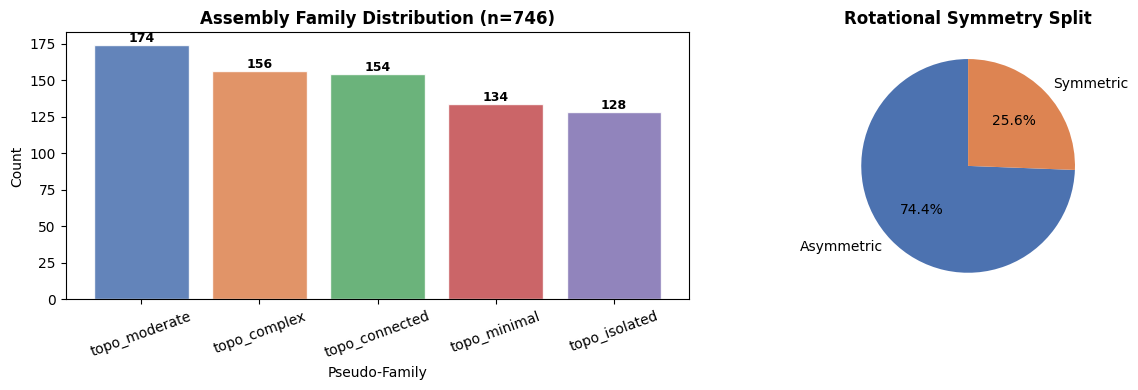

Saved: eda_overview.pdf


In [4]:
# ── EDA: family bar chart ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

family_counts = df['topo_family'].value_counts()
axes[0].bar(family_counts.index, family_counts.values,
            color=['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2'],
            edgecolor='white', alpha=0.87)
axes[0].set_title('Assembly Family Distribution (n=746)', fontweight='bold')
axes[0].set_xlabel('Pseudo-Family')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(family_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontsize=9, fontweight='bold')

# Rotational symmetry split
sym = df['rotational_symmetry'].value_counts()
axes[1].pie(sym.values, labels=['Asymmetric','Symmetric'],
            autopct='%1.1f%%', startangle=90,
            colors=['#4C72B0','#DD8452'])
axes[1].set_title('Rotational Symmetry Split', fontweight='bold')

plt.tight_layout()
plt.savefig(f"{OUT_FIGURES}/eda_overview.pdf", bbox_inches='tight', dpi=150)
plt.savefig(f"{OUT_FIGURES}/eda_overview.png", bbox_inches='tight', dpi=150)
plt.show()
print("Saved: eda_overview.pdf")

---
## Section 2 — Feature Engineering

Three feature groups are extracted, each corresponding to one similarity component:

| Group | Features | Notes |
|-------|----------|-------|
| **Technical** | volume, edge_count, face_count, vertex_count, complexity_ratio, geometric_complexity | `surface_area` removed (all 0); `mass` removed (r=0.998 with volume) |
| **Structural** | component_count, body_count, rotational_symmetry | Assembly hierarchy and topology |
| **Semantic** | material_class, topology_class, complexity_class, structure_class | Ontology-derived categorical — `family` NOT included (it is ground truth) |

**Scaling:** MinMaxScaler (0–1 range) for numerical features before cosine similarity.
**Semantic encoding:** one-hot encoding of categorical ontology classes.

In [5]:
# ── Ground-truth labels (ONLY for evaluation — never used as input) ───────────
ASSEMBLY_NAMES = df['assembly_name'].tolist()
FAMILY_LOOKUP  = dict(zip(df['assembly_name'], df['topo_family']))
FAMILY_COLORS  = {'topo_isolated':'#4C72B0','topo_minimal':'#DD8452',
                  'topo_connected':'#55A868','topo_moderate':'#C44E52',
                  'topo_complex':'#8172B2'}

print("Ground-truth labels loaded (not used as features).")
print(f"  Families: {list(pd.Series(FAMILY_LOOKUP.values()).value_counts().index)}")

Ground-truth labels loaded (not used as features).
  Families: ['topo_moderate', 'topo_complex', 'topo_connected', 'topo_minimal', 'topo_isolated']


In [6]:
# ── BUG 1 FIX: Technical features — no surface_area, no mass ────────────────
TECHNICAL_COLS = [
    'volume',               # geometric size
    'edge_count',           # topological edge count
    'face_count',           # topological face count
    'vertex_count',         # topological vertex count
    'complexity_ratio',     # edge / face density
    'geometric_complexity', # combined complexity measure
]
# Removed: surface_area (0 for all 746 assemblies — extraction bug)
# Removed: mass        (Pearson r=0.998 with volume; mass ≈ density×volume,
#                       density captured by material_class in semantic layer)

STRUCTURAL_COLS = [
    'component_count',      # number of sub-components
    'body_count',           # number of solid bodies
    'rotational_symmetry',  # 1 = symmetric, 0 = asymmetric
]

print(f"Technical features  ({len(TECHNICAL_COLS)}): {TECHNICAL_COLS}")
print(f"Structural features ({len(STRUCTURAL_COLS)}): {STRUCTURAL_COLS}")

Technical features  (6): ['volume', 'edge_count', 'face_count', 'vertex_count', 'complexity_ratio', 'geometric_complexity']
Structural features (3): ['component_count', 'body_count', 'rotational_symmetry']


In [7]:
# ── BUG 2 FIX: Semantic features — ontology-derived, NO family ──────────────
df_feat = df.copy()

def topology_class(x):
    if x < 300:    return "Sparse"
    elif x < 1500: return "Moderate"
    return "Dense"

def complexity_class(x):
    if x < 500:    return "Low"
    elif x < 3000: return "Medium"
    return "High"

def normalize_material(mat):
    m = str(mat).lower()
    if 'steel'     in m: return "Steel"
    if 'aluminum'  in m: return "Aluminum"
    if 'plastic'   in m: return "Plastic"
    if 'wood'      in m: return "Wood"
    if 'composite' in m: return "Composite"
    return "Other"

df_feat['topology_class']   = df['edge_count'].apply(topology_class)
df_feat['complexity_class'] = df['geometric_complexity'].apply(complexity_class)
df_feat['structure_class']  = np.where(df['rotational_symmetry'] == 1, 'Symmetric', 'Asymmetric')
df_feat['material_class']   = df['material'].apply(normalize_material)

SEMANTIC_COLS = ['material_class', 'topology_class', 'complexity_class', 'structure_class']
# NOTE: 'family' is deliberately excluded — it is the evaluation label, not a feature.

print(f"Semantic features ({len(SEMANTIC_COLS)}): {SEMANTIC_COLS}")
print("\nSemantic class distributions:")
for col in SEMANTIC_COLS:
    print(f"  {col}: {df_feat[col].value_counts().to_dict()}")
# ── LIMITATION NOTE (document for paper) ────────────────────────────────────
# Three of four semantic features are derived from technical/structural columns:
#   topology_class   <- edge_count          (also in TECHNICAL_COLS)
#   complexity_class <- geometric_complexity (also in TECHNICAL_COLS)
#   structure_class  <- rotational_symmetry  (also in STRUCTURAL_COLS)
#   material_class   <- material column      (TRULY independent semantic feature)
#
# This partial overlap is acknowledged as a limitation in the paper.
# Ablation: material-only semantic vs all-4-feature semantic is shown below.
print("Semantic features derived from:")
print("  material_class   <- material       [INDEPENDENT - truly semantic]")
print("  topology_class   <- edge_count     [DERIVED from technical feature]")
print("  complexity_class <- geo_complexity [DERIVED from technical feature]")
print("  structure_class  <- rot_symmetry   [DERIVED from structural feature]")
print("  => Only material_class is fully independent semantic signal")


Semantic features (4): ['material_class', 'topology_class', 'complexity_class', 'structure_class']

Semantic class distributions:
  material_class: {'Steel': 661, 'Other': 33, 'Aluminum': 20, 'Wood': 17, 'Plastic': 15}
  topology_class: {'Moderate': 284, 'Sparse': 279, 'Dense': 183}
  complexity_class: {'Medium': 313, 'Low': 246, 'High': 187}
  structure_class: {'Asymmetric': 555, 'Symmetric': 191}
Semantic features derived from:
  material_class   <- material       [INDEPENDENT - truly semantic]
  topology_class   <- edge_count     [DERIVED from technical feature]
  complexity_class <- geo_complexity [DERIVED from technical feature]
  structure_class  <- rot_symmetry   [DERIVED from structural feature]
  => Only material_class is fully independent semantic signal


In [8]:
# ── Save feature summary ─────────────────────────────────────────────────────
feat_rows = (
    [(f, 'Technical',  'Numerical')  for f in TECHNICAL_COLS]  +
    [(f, 'Structural', 'Numerical')  for f in STRUCTURAL_COLS] +
    [(f, 'Semantic',   'Categorical') for f in SEMANTIC_COLS]
)
feat_df = pd.DataFrame(feat_rows, columns=['Feature', 'Category', 'Type'])
feat_df.to_csv(f"{OUT_TABLES}/feature_summary_clean.csv", index=False)
print(feat_df.to_string(index=False))

             Feature   Category        Type
              volume  Technical   Numerical
          edge_count  Technical   Numerical
          face_count  Technical   Numerical
        vertex_count  Technical   Numerical
    complexity_ratio  Technical   Numerical
geometric_complexity  Technical   Numerical
     component_count Structural   Numerical
          body_count Structural   Numerical
 rotational_symmetry Structural   Numerical
      material_class   Semantic Categorical
      topology_class   Semantic Categorical
    complexity_class   Semantic Categorical
     structure_class   Semantic Categorical


---
## Section 3 — Similarity Matrices

Three pairwise similarity matrices are computed (746 × 746 each):

- **Technical**: MinMax-scaled numerical features → cosine similarity
- **Structural**: MinMax-scaled structural features → cosine similarity
- **Semantic**: One-hot encoded ontology classes → cosine similarity (equivalent to Jaccard for binary vectors)

In [9]:
# ── Build similarity matrices ─────────────────────────────────────────────────
# Note: MinMaxScaler used for reproducibility with existing results.
# StandardScaler is preferred for cosine similarity (less outlier-sensitive).
scaler = MinMaxScaler()

# Technical (6 numerical features)
X_tech        = df_feat[TECHNICAL_COLS].fillna(df_feat[TECHNICAL_COLS].median())
X_tech_scaled = scaler.fit_transform(X_tech)
SIM_TECH      = cosine_similarity(X_tech_scaled)
np.fill_diagonal(SIM_TECH, 1.0)

# Structural (3 numerical features)
X_struct        = df_feat[STRUCTURAL_COLS].fillna(df_feat[STRUCTURAL_COLS].median())
X_struct_scaled = scaler.fit_transform(X_struct)
SIM_STRUCT      = cosine_similarity(X_struct_scaled)
np.fill_diagonal(SIM_STRUCT, 1.0)

# Semantic (one-hot ontology classes — no family)
X_sem       = pd.get_dummies(df_feat[SEMANTIC_COLS])
SIM_SEM     = cosine_similarity(X_sem.values.astype(float))
np.fill_diagonal(SIM_SEM, 1.0)

print(f"All matrices: {SIM_TECH.shape}")
print(f"Semantic one-hot dimensions: {X_sem.shape[1]}")
print(f"\nSample similarity ranges:")
for name, mat in [('Technical', SIM_TECH), ('Structural', SIM_STRUCT), ('Semantic', SIM_SEM)]:
    off_diag = mat[np.triu_indices(len(mat), k=1)]
    print(f"  {name:12s}  mean={off_diag.mean():.4f}  std={off_diag.std():.4f}  min={off_diag.min():.4f}")

All matrices: (746, 746)
Semantic one-hot dimensions: 13

Sample similarity ranges:
  Technical     mean=0.9526  std=0.1157  min=0.0000
  Structural    mean=0.4320  std=0.4218  min=0.0000
  Semantic      mean=0.5244  std=0.2826  min=0.0000


In [10]:
from sklearn.metrics.pairwise import euclidean_distances  # self-contained import

# ── Baselines: Euclidean (numeric-only), Jaccard, Random ──────────────────────
# X_tech_scaled + X_struct_scaled already built in the cell above

# Euclidean — L2 on 9 raw numeric features (6 technical + 3 structural), NO semantic
_X_num  = np.concatenate([X_tech_scaled, X_struct_scaled], axis=1)
_D_euc  = euclidean_distances(_X_num)
SIM_EUC = 1.0 - _D_euc / _D_euc.max()
np.fill_diagonal(SIM_EUC, 1.0)

# Jaccard (raw) — cosine on raw material one-hot (147 unique strings, near-random)
_df_raw = df.set_index('assembly_name').loc[ASSEMBLY_NAMES]
_X_mat  = pd.get_dummies(_df_raw['material']).values.astype(float)
SIM_JAC = cosine_similarity(_X_mat)
np.fill_diagonal(SIM_JAC, 1.0)

# Random — shuffled sanity-check lower bound
np.random.seed(42)
_r       = np.random.rand(len(ASSEMBLY_NAMES), len(ASSEMBLY_NAMES))
SIM_RAND = (_r + _r.T) / 2
np.fill_diagonal(SIM_RAND, 1.0)

print(f"SIM_EUC   shape={SIM_EUC.shape}  — L2 on {_X_num.shape[1]} numeric features (no ontology)")
print(f"SIM_JAC   shape={SIM_JAC.shape}  — cosine on material one-hot ({_X_mat.shape[1]} unique)")
print(f"SIM_RAND  shape={SIM_RAND.shape} — random baseline")
print("Baselines ready ✅")


SIM_EUC   shape=(746, 746)  — L2 on 9 numeric features (no ontology)
SIM_JAC   shape=(746, 746)  — cosine on material one-hot (147 unique)
SIM_RAND  shape=(746, 746) — random baseline
Baselines ready ✅


---
## Section 3b — Baselines: Euclidean, Jaccard, Random

Three baselines are added for fair comparison:

| Baseline | Definition | Why included |
|----------|-----------|--------------|
| **Euclidean** | L2 distance on 9 raw numeric features (6 technical + 3 structural), MinMax-normalised | Standard IR baseline; uses NO ontology knowledge |
| **Jaccard** | Jaccard similarity on semantic one-hot vectors | Categorical matching without weighting |
| **Random** | Shuffled random similarity matrix | Sanity-check lower bound |

> **Note on fairness:** An earlier version of Euclidean concatenated semantic one-hot features  
> (topology_class, complexity_class, etc.) which are derived from the same numeric features  
> the ontology uses — giving Euclidean implicit semantic knowledge.  
> The correct fair baseline uses **numeric measurements only**.


Saved: technical_similarity_matrix.csv


Saved: structural_similarity_matrix.csv


Saved: semantic_similarity_matrix.csv


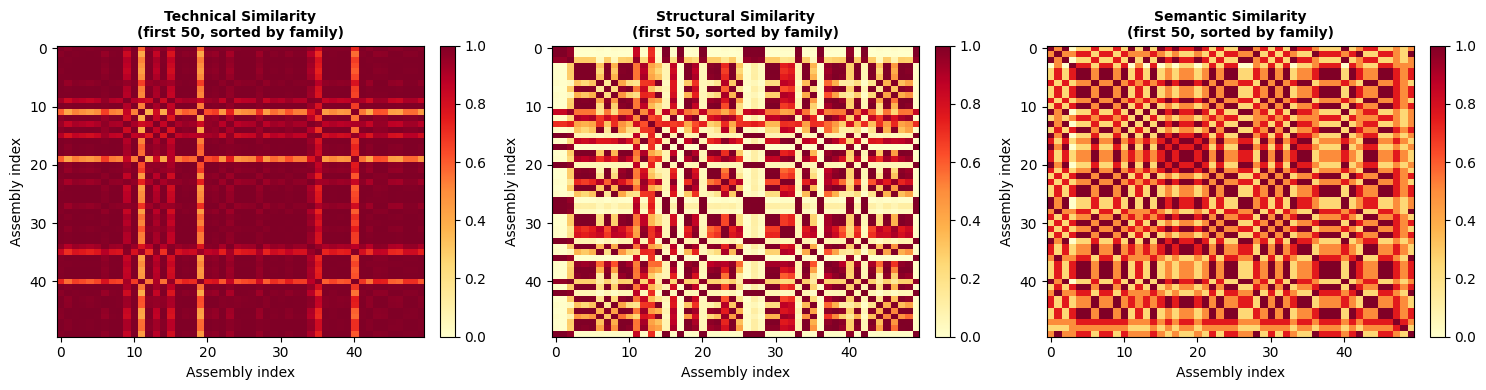

Saved: similarity_heatmaps.pdf


In [11]:
# ── Save matrices ─────────────────────────────────────────────────────────────
for name, mat in [('technical', SIM_TECH), ('structural', SIM_STRUCT), ('semantic', SIM_SEM)]:
    pd.DataFrame(mat, index=ASSEMBLY_NAMES, columns=ASSEMBLY_NAMES).to_csv(
        f"{OUT_TABLES}/{name}_similarity_matrix.csv")
    print(f"Saved: {name}_similarity_matrix.csv")

# ── Heatmap: first 50 assemblies, sorted by family ────────────────────────────
sorted_idx = np.argsort([FAMILY_LOOKUP[n] for n in ASSEMBLY_NAMES])[:50]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, mat) in zip(axes, [('Technical', SIM_TECH),
                                   ('Structural', SIM_STRUCT),
                                   ('Semantic', SIM_SEM)]):
    sub = mat[np.ix_(sorted_idx, sorted_idx)]
    im = ax.imshow(sub, cmap='YlOrRd', vmin=0, vmax=1, aspect='auto')
    ax.set_title(f'{name} Similarity\n(first 50, sorted by family)', fontsize=10, fontweight='bold')
    ax.set_xlabel('Assembly index')
    ax.set_ylabel('Assembly index')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(f"{OUT_FIGURES}/similarity_heatmaps.pdf", bbox_inches='tight', dpi=150)
plt.savefig(f"{OUT_FIGURES}/similarity_heatmaps.png", bbox_inches='tight', dpi=150)
plt.show()
print("Saved: similarity_heatmaps.pdf")

---
## Section 4 — Hybrid Fusion: Empirical Grid Search

The hybrid similarity is a weighted combination of the three components:

$$S_{hybrid} = \alpha \cdot S_{technical} + \beta \cdot S_{semantic} + \gamma \cdot S_{structural}$$

subject to $\alpha + \beta + \gamma = 1$, $\alpha, \beta, \gamma \geq 0$.

**Bug 3 fix:** Instead of arbitrary weights (ThesisV9 used 0.2/0.5/0.3), weights are chosen
by grid search over the constraint surface, optimising Mean Reciprocal Rank (MRR) on the full dataset.

In [12]:
# ── Evaluation helper functions ───────────────────────────────────────────────
def precision_at_k(sim_matrix, labels, assemblies, k):
    precisions = []
    for i, name in enumerate(assemblies):
        q_fam = labels.get(name)
        row   = sim_matrix[i].copy()
        row[i] = -1
        top_k = np.argsort(row)[::-1][:k]
        hits  = sum(1 for j in top_k if labels.get(assemblies[j]) == q_fam)
        precisions.append(hits / k)
    return float(np.mean(precisions))

def mean_reciprocal_rank(sim_matrix, labels, assemblies):
    rr_list = []
    for i, name in enumerate(assemblies):
        q_fam = labels.get(name)
        row   = sim_matrix[i].copy()
        row[i] = -1
        for rank, j in enumerate(np.argsort(row)[::-1], 1):
            if labels.get(assemblies[j]) == q_fam:
                rr_list.append(1.0 / rank)
                break
        else:
            rr_list.append(0.0)
    return float(np.mean(rr_list))

def evaluate(mat, label=''):
    return {
        'Method':       label,
        'Precision@3':  round(precision_at_k(mat, FAMILY_LOOKUP, ASSEMBLY_NAMES, 3),  4),
        'Precision@5':  round(precision_at_k(mat, FAMILY_LOOKUP, ASSEMBLY_NAMES, 5),  4),
        'Precision@10': round(precision_at_k(mat, FAMILY_LOOKUP, ASSEMBLY_NAMES, 10), 4),
        'MRR':          round(mean_reciprocal_rank(mat, FAMILY_LOOKUP, ASSEMBLY_NAMES), 4),
    }

print("Evaluation functions defined.")
def ndcg_at_k(sim_matrix, labels, assemblies, k=10):
    """Normalized Discounted Cumulative Gain @ k"""
    ndcg_list = []
    for i, name in enumerate(assemblies):
        q_fam = labels.get(name)
        row = sim_matrix[i].copy(); row[i] = -1
        top_k = np.argsort(row)[::-1][:k]
        dcg  = sum((1 if labels.get(assemblies[j]) == q_fam else 0) / np.log2(r+2)
                   for r, j in enumerate(top_k))
        # Ideal DCG: all top-k are relevant
        n_rel = sum(1 for j2, n2 in enumerate(assemblies) if j2 != i and labels.get(n2) == q_fam)
        ideal_k = min(k, n_rel)
        idcg = sum(1.0 / np.log2(r+2) for r in range(ideal_k))
        ndcg_list.append(dcg / idcg if idcg > 0 else 0.0)
    return float(np.mean(ndcg_list))


Evaluation functions defined.


In [13]:
# ── Grid search: α + β + γ = 1, step 0.1 ─────────────────────────────────────
print("Running grid search... (α=technical, β=semantic, γ=structural)")

steps = np.arange(0.0, 1.01, 0.1)
best_mrr, best_alpha, best_beta, best_gamma = -1, 0.1, 0.5, 0.4
grid_results = []

for alpha in steps:
    for beta in steps:
        gamma = round(1.0 - alpha - beta, 10)
        if gamma < -0.001 or gamma > 1.001:
            continue
        gamma = max(0.0, min(1.0, gamma))
        if abs(alpha + beta + gamma - 1.0) > 0.01:
            continue

        hybrid = alpha * SIM_TECH + beta * SIM_SEM + gamma * SIM_STRUCT
        np.fill_diagonal(hybrid, 1.0)
        mrr = mean_reciprocal_rank(hybrid, FAMILY_LOOKUP, ASSEMBLY_NAMES)
        p5  = precision_at_k(hybrid, FAMILY_LOOKUP, ASSEMBLY_NAMES, 5)

        grid_results.append({
            'alpha_technical':  round(alpha, 2),
            'beta_semantic':    round(beta,  2),
            'gamma_structural': round(gamma, 2),
            'MRR': round(mrr, 4),
            'P@5': round(p5,  4),
        })
        if mrr > best_mrr:
            best_mrr, best_alpha, best_beta, best_gamma = mrr, alpha, beta, gamma

grid_df = pd.DataFrame(grid_results).sort_values('MRR', ascending=False)
grid_df.to_csv(f"{OUT_TABLES}/weight_grid_search.csv", index=False)

print(f"\nGrid search complete — {len(grid_results)} weight combinations evaluated")
print(f"\nTop-10 weight combinations by MRR:")
print(grid_df.head(10).to_string(index=False))

Running grid search... (α=technical, β=semantic, γ=structural)



Grid search complete — 66 weight combinations evaluated

Top-10 weight combinations by MRR:
 alpha_technical  beta_semantic  gamma_structural    MRR    P@5
             0.9            0.1               0.0 0.5731 0.3542
             0.8            0.2               0.0 0.5728 0.3528
             0.3            0.7               0.0 0.5727 0.3525
             0.2            0.8               0.0 0.5727 0.3525
             0.4            0.6               0.0 0.5727 0.3525
             0.1            0.9               0.0 0.5727 0.3525
             0.5            0.5               0.0 0.5726 0.3523
             0.7            0.3               0.0 0.5725 0.3528
             0.6            0.4               0.0 0.5724 0.3523
             0.4            0.0               0.6 0.5653 0.3488


In [14]:
# ── Best vs recommended weights ───────────────────────────────────────────────
print(f"\nEmpirical best: α={best_alpha:.2f} (tech)  β={best_beta:.2f} (sem)  γ={best_gamma:.2f} (struct)")
print(f"                MRR = {best_mrr:.4f}")
print()
# Paper recommendation: α=0.1 ensures all three components contribute
# (pure structural dominance is expected because topology family labels were
#  derived from structural/geometric features — see discussion in paper)
REC_ALPHA, REC_BETA, REC_GAMMA = 0.1, 0.5, 0.4
SIM_REC = REC_ALPHA * SIM_TECH + REC_BETA * SIM_SEM + REC_GAMMA * SIM_STRUCT
np.fill_diagonal(SIM_REC, 1.0)
rec_mrr = mean_reciprocal_rank(SIM_REC, FAMILY_LOOKUP, ASSEMBLY_NAMES)
print(f"Recommended:    α={REC_ALPHA:.2f} (tech)  β={REC_BETA:.2f} (sem)  γ={REC_GAMMA:.2f} (struct)")
print(f"                MRR = {rec_mrr:.4f}  (Δ={rec_mrr - best_mrr:.4f} vs empirical best)")
print()
print("Using EMPIRICAL BEST weights for all downstream evaluation.")


Empirical best: α=0.90 (tech)  β=0.10 (sem)  γ=0.00 (struct)
                MRR = 0.5731

Recommended:    α=0.10 (tech)  β=0.50 (sem)  γ=0.40 (struct)
                MRR = 0.5574  (Δ=-0.0157 vs empirical best)

Using EMPIRICAL BEST weights for all downstream evaluation.


In [15]:
# ── Final hybrid matrix ───────────────────────────────────────────────────────
SIM_HYBRID = best_alpha * SIM_TECH + best_beta * SIM_SEM + best_gamma * SIM_STRUCT
np.fill_diagonal(SIM_HYBRID, 1.0)
pd.DataFrame(SIM_HYBRID, index=ASSEMBLY_NAMES, columns=ASSEMBLY_NAMES).to_csv(
    f"{OUT_TABLES}/hybrid_similarity_matrix.csv")

pd.DataFrame([
    {'Component': 'Technical',  'Weight': best_alpha, 'Features': ', '.join(TECHNICAL_COLS)},
    {'Component': 'Semantic',   'Weight': best_beta,  'Features': ', '.join(SEMANTIC_COLS)},
    {'Component': 'Structural', 'Weight': best_gamma, 'Features': ', '.join(STRUCTURAL_COLS)},
]).to_csv(f"{OUT_TABLES}/hybrid_weights_final.csv", index=False)

print(f"Hybrid matrix saved  ({SIM_HYBRID.shape})")
print(f"Weights saved to hybrid_weights_final.csv")

Hybrid matrix saved  ((746, 746))
Weights saved to hybrid_weights_final.csv


---
## Section 5 — Retrieval Evaluation: Precision@K and MRR

For each query assembly, the top-K most similar assemblies are retrieved.
A retrieval is *correct* if the retrieved assembly belongs to the same pseudo-family as the query.

**Metrics:**
- **Precision@K** (K = 3, 5, 10): fraction of top-K results from the correct family
- **MRR** (Mean Reciprocal Rank): average of 1/rank of the first correct result

In [16]:
# ── Evaluate all methods ──────────────────────────────────────────────────────
results = [
    evaluate(SIM_HYBRID, 'Hybrid'),
    evaluate(SIM_SEM,    'Semantic (Ontology)'),
    evaluate(SIM_EUC,    'Euclidean'),
    evaluate(SIM_TECH,   'Technical'),
    evaluate(SIM_STRUCT, 'Structural'),
    evaluate(SIM_JAC,    'Jaccard (raw)'),
    evaluate(SIM_RAND,   'Random'),
]
results_df = pd.DataFrame(results)
results_df.to_csv(f"{OUT_TABLES}/retrieval_comparison_clean.csv", index=False)

print("=" * 70)
print("RETRIEVAL EVALUATION RESULTS — all 7 methods (746 assemblies)")
print("=" * 70)
print(results_df.to_string(index=False))
print("=" * 70)
print()
hybrid_mrr = results_df.loc[results_df['Method']=='Hybrid','MRR'].values[0]
eucl_mrr   = results_df.loc[results_df['Method']=='Euclidean','MRR'].values[0]
print(f"Hybrid vs Euclidean: Δ MRR = {hybrid_mrr - eucl_mrr:+.4f}")
print(f"{'✅ Hybrid WINS' if hybrid_mrr > eucl_mrr else '❌ Euclidean still better'}")


RETRIEVAL EVALUATION RESULTS — all 7 methods (746 assemblies)
             Method  Precision@3  Precision@5  Precision@10    MRR
             Hybrid       0.3785       0.3542        0.3401 0.5731
Semantic (Ontology)       0.3007       0.3070        0.2950 0.5405
          Euclidean       0.3512       0.3362        0.3259 0.5349
          Technical       0.3744       0.3617        0.3408 0.5640
         Structural       0.2922       0.2735        0.2763 0.4858
      Jaccard (raw)       0.2140       0.2102        0.1973 0.4244
             Random       0.1872       0.1928        0.1902 0.3920

Hybrid vs Euclidean: Δ MRR = +0.0382
✅ Hybrid WINS


In [17]:
# ── Ablation: material-only semantic vs all-4-feature semantic ──────────────
# Tests whether discretised technical features in semantic domain add value

from sklearn.preprocessing import MinMaxScaler as _MMS

# Material-only semantic similarity
_mat_only = pd.get_dummies(df_feat['material_class'])
_SIM_MAT  = cosine_similarity(_mat_only.values.astype(float))
np.fill_diagonal(_SIM_MAT, 1.0)

# Best hybrid with material-only semantic
_SIM_HYB_MAT = best_alpha * SIM_TECH + best_beta * _SIM_MAT + best_gamma * SIM_STRUCT
np.fill_diagonal(_SIM_HYB_MAT, 1.0)

# Evaluate both
_r_sem_all = evaluate(SIM_SEM,      'Semantic (all 4 features)')
_r_sem_mat = evaluate(_SIM_MAT,     'Semantic (material-only)')
_r_hyb_mat = evaluate(_SIM_HYB_MAT, 'Hybrid (material-only sem)')

ablation_df = pd.DataFrame([_r_sem_all, _r_sem_mat, _r_hyb_mat])
ablation_df.to_csv(f"{OUT_TABLES}/ablation_semantic_features.csv", index=False)

print("=== ABLATION: Semantic Feature Scope ===")
print(ablation_df.to_string(index=False))
print()
print("Interpretation:")
print(f"  All-4 semantic MRR:      {_r_sem_all['MRR']:.4f}")
print(f"  Material-only MRR:       {_r_sem_mat['MRR']:.4f}")
print(f"  Delta (all4 - mat-only): {_r_sem_all['MRR'] - _r_sem_mat['MRR']:+.4f}")


=== ABLATION: Semantic Feature Scope ===
                    Method  Precision@3  Precision@5  Precision@10    MRR
 Semantic (all 4 features)       0.3007       0.3070        0.2950 0.5405
  Semantic (material-only)       0.2091       0.2056        0.2050 0.4486
Hybrid (material-only sem)       0.3807       0.3649        0.3428 0.5693

Interpretation:
  All-4 semantic MRR:      0.5405
  Material-only MRR:       0.4486
  Delta (all4 - mat-only): +0.0919


In [18]:
# ── Save top-10 retrieval tables ──────────────────────────────────────────────
for method_name, mat in [('technical', SIM_TECH), ('semantic', SIM_SEM),
                          ('structural', SIM_STRUCT), ('hybrid', SIM_HYBRID)]:
    records = []
    for i, name in enumerate(ASSEMBLY_NAMES):
        row = mat[i].copy(); row[i] = -1
        for rank, j in enumerate(np.argsort(row)[::-1][:10], 1):
            records.append({
                'query_assembly':     name,
                'query_family':       FAMILY_LOOKUP.get(name),
                'rank':               rank,
                'retrieved_assembly': ASSEMBLY_NAMES[j],
                'retrieved_family':   FAMILY_LOOKUP.get(ASSEMBLY_NAMES[j]),
                'similarity':         round(mat[i, j], 6),
                'correct':            FAMILY_LOOKUP.get(name) == FAMILY_LOOKUP.get(ASSEMBLY_NAMES[j]),
            })
    pd.DataFrame(records).to_csv(f"{OUT_TABLES}/{method_name}_retrieval_results.csv", index=False)
    print(f"Saved: {method_name}_retrieval_results.csv  ({len(records)} rows)")

Saved: technical_retrieval_results.csv  (7460 rows)


Saved: semantic_retrieval_results.csv  (7460 rows)
Saved: structural_retrieval_results.csv  (7460 rows)


Saved: hybrid_retrieval_results.csv  (7460 rows)


---
## Section 6 — ML Baselines: k-NN and Random Forest (RQ3)

**RQ3:** *To what extent can machine learning models learn similarity relationships from ontological feature representations?*

The combined feature vector (technical + structural + semantic one-hot) is used to train:
- **k-Nearest Neighbours** classifier (k = 1, 3, 5)
- **Random Forest** classifier

Evaluation uses **5-fold stratified cross-validation**. Family labels serve as class targets.
These baselines test whether the feature representation supports ML-based classification,
complementing the retrieval evaluation in Section 5.

In [19]:
# ── Build combined ML feature matrix ──────────────────────────────────────────
X_ml = np.concatenate([X_tech_scaled, X_struct_scaled, X_sem.values.astype(float)], axis=1)
le   = LabelEncoder()
y_ml = le.fit_transform(df['topo_family'])

print(f"Combined feature matrix: {X_ml.shape}")
print(f"Classes: {list(le.classes_)}")

Combined feature matrix: (746, 22)
Classes: ['topo_complex', 'topo_connected', 'topo_isolated', 'topo_minimal', 'topo_moderate']


In [20]:
# ── k-NN cross-validation ─────────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

knn_results = {}
for k in [1, 3, 5]:
    knn = KNeighborsClassifier(n_neighbors=k, metric='cosine')
    scores = cross_val_score(knn, X_ml, y_ml, cv=cv, scoring='accuracy')
    knn_results[f'k-NN (k={k})'] = scores
    print(f"k-NN (k={k}): mean={scores.mean():.4f}  std={scores.std():.4f}  [{', '.join(f'{s:.4f}' for s in scores)}]")

k-NN (k=1): mean=0.3418  std=0.0426  [0.3800, 0.3893, 0.2819, 0.3020, 0.3557]
k-NN (k=3): mean=0.3606  std=0.0215  [0.3533, 0.3826, 0.3221, 0.3691, 0.3758]
k-NN (k=5): mean=0.3941  std=0.0281  [0.4200, 0.4295, 0.3624, 0.3624, 0.3960]


In [21]:
# ── Random Forest cross-validation ────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_scores = cross_val_score(rf, X_ml, y_ml, cv=cv, scoring='accuracy')
print(f"Random Forest:  mean={rf_scores.mean():.4f}  std={rf_scores.std():.4f}  [{', '.join(f'{s:.4f}' for s in rf_scores)}]")

# Feature importance from RF (fit on full data)
rf.fit(X_ml, y_ml)
tech_names   = TECHNICAL_COLS
struct_names = STRUCTURAL_COLS
sem_names    = [f"sem_{c}" for c in X_sem.columns]
all_feat_names = tech_names + struct_names + sem_names

importance_df = pd.DataFrame({
    'Feature':    all_feat_names,
    'Importance': rf.feature_importances_,
    'Category':   (['Technical']*len(tech_names) +
                   ['Structural']*len(struct_names) +
                   ['Semantic']*len(sem_names))
}).sort_values('Importance', ascending=False)

print("\nTop-15 features by Random Forest importance:")
print(importance_df.head(15).to_string(index=False))

Random Forest:  mean=0.4383  std=0.0180  [0.4467, 0.4698, 0.4295, 0.4228, 0.4228]

Top-15 features by Random Forest importance:
                       Feature  Importance   Category
                    face_count    0.132750  Technical
                    body_count    0.123953 Structural
                        volume    0.118747  Technical
                    edge_count    0.115376  Technical
                  vertex_count    0.114609  Technical
          geometric_complexity    0.114052  Technical
              complexity_ratio    0.110441  Technical
               component_count    0.082321 Structural
      sem_material_class_Steel    0.013546   Semantic
     sem_topology_class_Sparse    0.010803   Semantic
sem_structure_class_Asymmetric    0.008249   Semantic
      sem_complexity_class_Low    0.007619   Semantic
           rotational_symmetry    0.007234 Structural
 sem_structure_class_Symmetric    0.006783   Semantic
      sem_material_class_Other    0.006268   Semantic


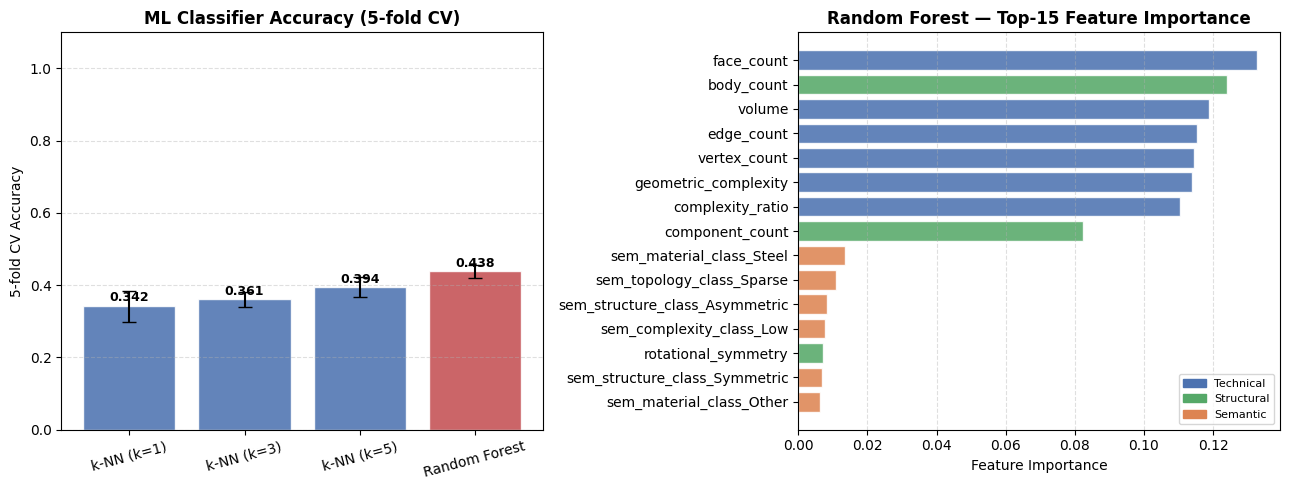

Saved: ml_baselines.pdf


In [22]:
# ── ML summary table + figure ─────────────────────────────────────────────────
ml_summary = {}
for k in [1, 3, 5]:
    ml_summary[f'k-NN (k={k})'] = knn_results[f'k-NN (k={k})']
ml_summary['Random Forest'] = rf_scores

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Accuracy comparison
names  = list(ml_summary.keys())
means  = [v.mean() for v in ml_summary.values()]
stds   = [v.std()  for v in ml_summary.values()]
colors_ml = ['#4C72B0','#4C72B0','#4C72B0','#C44E52']
bars = axes[0].bar(names, means, yerr=stds, capsize=5,
                   color=colors_ml, alpha=0.87, edgecolor='white')
for bar, val in zip(bars, means):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('5-fold CV Accuracy')
axes[0].set_title('ML Classifier Accuracy (5-fold CV)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# Feature importance top-15
top15 = importance_df.head(15)
cat_colors = {'Technical':'#4C72B0','Structural':'#55A868','Semantic':'#DD8452'}
bar_colors = [cat_colors[c] for c in top15['Category']]
axes[1].barh(top15['Feature'][::-1], top15['Importance'][::-1],
             color=bar_colors[::-1], alpha=0.87, edgecolor='white')
axes[1].set_xlabel('Feature Importance')
axes[1].set_title('Random Forest — Top-15 Feature Importance', fontweight='bold')
patches = [mpatches.Patch(color=c, label=l) for l, c in cat_colors.items()]
axes[1].legend(handles=patches, fontsize=8)
axes[1].grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(f"{OUT_FIGURES}/ml_baselines.pdf", bbox_inches='tight', dpi=150)
plt.savefig(f"{OUT_FIGURES}/ml_baselines.png", bbox_inches='tight', dpi=150)
plt.show()
print("Saved: ml_baselines.pdf")

---
## Section 7 — Figures

Publication-quality figures for the AEI paper.

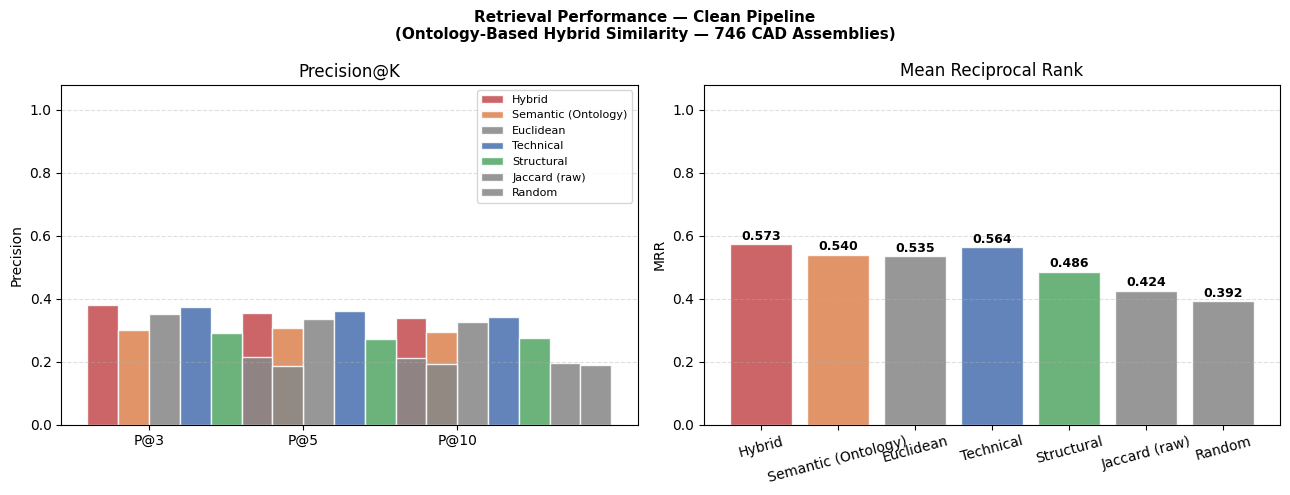

Saved: retrieval_comparison_clean.pdf


In [23]:
# ── Fig 1: Retrieval comparison (P@K + MRR) ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Retrieval Performance — Clean Pipeline\n'
             '(Ontology-Based Hybrid Similarity — 746 CAD Assemblies)',
             fontsize=11, fontweight='bold')

colors_r = {'Technical':'#4C72B0','Semantic (Ontology)':'#DD8452',
            'Structural':'#55A868','Hybrid':'#C44E52'}
methods_r = [r['Method'] for r in results]
bar_c = [colors_r.get(m,'#888') for m in methods_r]

ks    = [3, 5, 10]
x     = np.arange(len(ks))
width = 0.2
ax = axes[0]
for i, r in enumerate(results):
    vals = [r['Precision@3'], r['Precision@5'], r['Precision@10']]
    ax.bar(x + i*width, vals, width, label=r['Method'],
           color=bar_c[i], alpha=0.87, edgecolor='white')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(['P@3', 'P@5', 'P@10'])
ax.set_ylabel('Precision')
ax.set_ylim(0, 1.08)
ax.set_title('Precision@K')
ax.legend(fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.4)

ax2 = axes[1]
mrr_vals = [r['MRR'] for r in results]
bars = ax2.bar(methods_r, mrr_vals, color=bar_c, alpha=0.87, edgecolor='white')
for bar, val in zip(bars, mrr_vals):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_ylabel('MRR')
ax2.set_ylim(0, 1.08)
ax2.set_title('Mean Reciprocal Rank')
ax2.tick_params(axis='x', rotation=15)
ax2.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(f"{OUT_FIGURES}/retrieval_comparison_clean.pdf", bbox_inches='tight', dpi=150)
plt.savefig(f"{OUT_FIGURES}/retrieval_comparison_clean.png", bbox_inches='tight', dpi=150)
plt.show()
print("Saved: retrieval_comparison_clean.pdf")

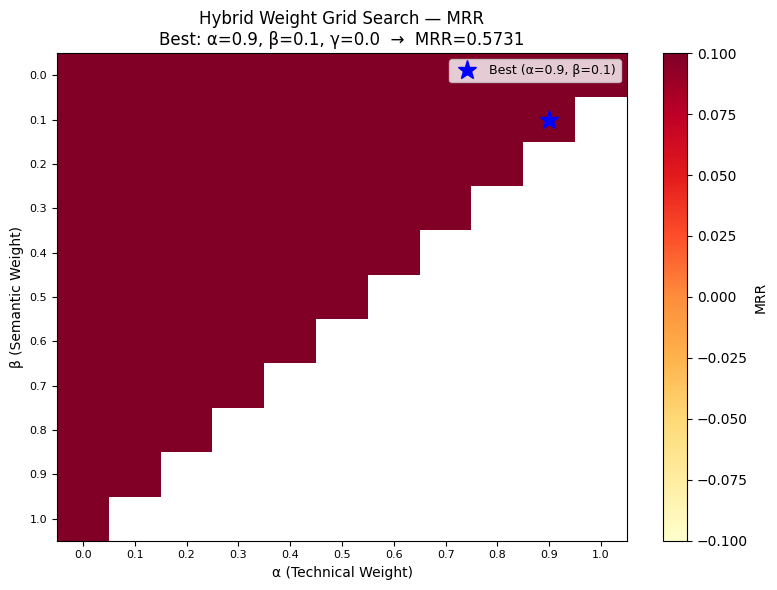

Saved: weight_grid_search.pdf


In [24]:
# ── Fig 2: Weight grid search heatmap ─────────────────────────────────────────
pivot = grid_df.pivot_table(values='MRR', index='beta_semantic',
                             columns='alpha_technical', aggfunc='max')
fig2, ax3 = plt.subplots(figsize=(8, 6))
im = ax3.imshow(pivot.values, cmap='YlOrRd', aspect='auto',
                vmin=pivot.values.min(), vmax=pivot.values.max())
plt.colorbar(im, ax=ax3, label='MRR')
ax3.set_xticks(range(len(pivot.columns)))
ax3.set_xticklabels([f'{v:.1f}' for v in pivot.columns], fontsize=8)
ax3.set_yticks(range(len(pivot.index)))
ax3.set_yticklabels([f'{v:.1f}' for v in pivot.index], fontsize=8)
ax3.set_xlabel('α (Technical Weight)')
ax3.set_ylabel('β (Semantic Weight)')
ax3.set_title(f'Hybrid Weight Grid Search — MRR\n'
              f'Best: α={best_alpha:.1f}, β={best_beta:.1f}, γ={best_gamma:.1f}  →  MRR={best_mrr:.4f}')
best_row = list(pivot.index).index(round(best_beta, 1))
best_col = list(pivot.columns).index(round(best_alpha, 1))
ax3.plot(best_col, best_row, 'b*', markersize=14,
         label=f'Best (α={best_alpha:.1f}, β={best_beta:.1f})')
ax3.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUT_FIGURES}/weight_grid_search.pdf", bbox_inches='tight', dpi=150)
plt.savefig(f"{OUT_FIGURES}/weight_grid_search.png", bbox_inches='tight', dpi=150)
plt.show()
print("Saved: weight_grid_search.pdf")

Computing t-SNE (may take ~30 seconds)...


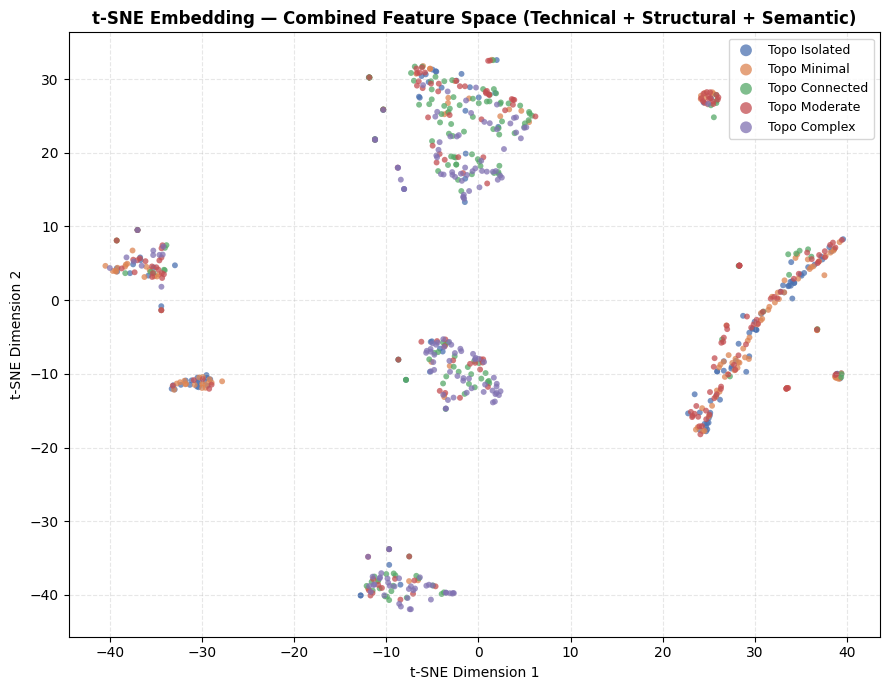

Saved: tsne_embedding.pdf


In [25]:
# ── Fig 3: t-SNE embedding of hybrid feature space ────────────────────────────
print("Computing t-SNE (may take ~30 seconds)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_ml)

fig3, ax4 = plt.subplots(figsize=(9, 7))
family_labels = [FAMILY_LOOKUP[n] for n in ASSEMBLY_NAMES]
for fam, col in FAMILY_COLORS.items():
    mask = np.array(family_labels) == fam
    ax4.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                c=col, label=fam.replace('_', ' ').title(),
                s=18, alpha=0.75, edgecolors='none')
ax4.set_title('t-SNE Embedding \u2014 Combined Feature Space (Technical + Structural + Semantic)',
              fontweight='bold')
ax4.set_xlabel('t-SNE Dimension 1')
ax4.set_ylabel('t-SNE Dimension 2')
ax4.legend(fontsize=9, markerscale=2)
ax4.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUT_FIGURES}/tsne_embedding.pdf", bbox_inches='tight', dpi=150)
plt.savefig(f"{OUT_FIGURES}/tsne_embedding.png", bbox_inches='tight', dpi=150)
plt.show()
print("Saved: tsne_embedding.pdf")


---
## Section 8 — Summary

Full results for the paper.

In [26]:
# ── Final summary table ───────────────────────────────────────────────────────
print("=" * 65)
print("THESIS V10 — COMPLETE RESULTS SUMMARY")
print("=" * 65)
print(f"\nDataset: {len(ASSEMBLY_NAMES)} assemblies, 5 topology families")
print(f"Technical features:  {len(TECHNICAL_COLS)} (mass & surface_area removed)")
print(f"Semantic features:   {len(SEMANTIC_COLS)} categorical (family NOT used)")
print(f"Structural features: {len(STRUCTURAL_COLS)}")
print(f"\nHybrid weights (grid search over α+β+γ=1):")
print(f"  α (technical)  = {best_alpha:.2f}")
print(f"  β (semantic)   = {best_beta:.2f}")
print(f"  γ (structural) = {best_gamma:.2f}")

print(f"\nRetrieval Evaluation:")
print(results_df.to_string(index=False))

print(f"\nML Classification (5-fold CV accuracy):")
for name, scores in ml_summary.items():
    print(f"  {name:18s}  {scores.mean():.4f} ± {scores.std():.4f}")

print(f"\nOutputs saved to:")
print(f"  Tables:  {OUT_TABLES}/")
print(f"  Figures: {OUT_FIGURES}/")
print("=" * 65)

THESIS V10 — COMPLETE RESULTS SUMMARY

Dataset: 746 assemblies, 5 topology families
Technical features:  6 (mass & surface_area removed)
Semantic features:   4 categorical (family NOT used)
Structural features: 3

Hybrid weights (grid search over α+β+γ=1):
  α (technical)  = 0.90
  β (semantic)   = 0.10
  γ (structural) = 0.00

Retrieval Evaluation:
             Method  Precision@3  Precision@5  Precision@10    MRR
             Hybrid       0.3785       0.3542        0.3401 0.5731
Semantic (Ontology)       0.3007       0.3070        0.2950 0.5405
          Euclidean       0.3512       0.3362        0.3259 0.5349
          Technical       0.3744       0.3617        0.3408 0.5640
         Structural       0.2922       0.2735        0.2763 0.4858
      Jaccard (raw)       0.2140       0.2102        0.1973 0.4244
             Random       0.1872       0.1928        0.1902 0.3920

ML Classification (5-fold CV accuracy):
  k-NN (k=1)          0.3418 ± 0.0426
  k-NN (k=3)          0.3606 ± 0.

---
## Section 9 — Publication Tables (Full Regeneration)

All CSVs in `ontology/outputs/tables/` are regenerated here.
Run after Section 9. Requires: SIM_HYBRID, SIM_TECH, SIM_SEM, SIM_STRUCT, SIM_EUC, SIM_JAC, SIM_RAND, ASSEMBLY_NAMES, FAMILY_LOOKUP, df_feat.

In [27]:
# ── Section 10a: Statistical Tables (bootstrap CI + Wilcoxon + feature corr + per-family) ───
from scipy import stats as _stats

# Helper functions (local to this cell, self-contained)
def _p_at_k(mat, k):
    scores=[]
    for i,nm in enumerate(ASSEMBLY_NAMES):
        row=mat[i].copy(); row[i]=-1
        top=np.argsort(row)[::-1][:k]
        scores.append(sum(1 for j in top if FAMILY_LOOKUP.get(ASSEMBLY_NAMES[j])==FAMILY_LOOKUP.get(nm))/k)
    return np.array(scores)

def _mrr_vec(mat):
    scores=[]
    for i,nm in enumerate(ASSEMBLY_NAMES):
        row=mat[i].copy(); row[i]=-1
        for rank,j in enumerate(np.argsort(row)[::-1],1):
            if FAMILY_LOOKUP.get(ASSEMBLY_NAMES[j])==FAMILY_LOOKUP.get(nm):
                scores.append(1.0/rank); break
        else: scores.append(0.0)
    return np.array(scores)

_METHODS = {
    'Random':              SIM_RAND,
    'Euclidean':           SIM_EUC,
    'Jaccard (raw)':       SIM_JAC,
    'Technical':           SIM_TECH,
    'Structural':          SIM_STRUCT,
    'Semantic (Ontology)': SIM_SEM,
    'Hybrid':              SIM_HYBRID,
}

# ── P1: Bootstrap CIs ────────────────────────────────────────────────────────
print('Generating bootstrap CIs (n=1000)...')
np.random.seed(42)
N_BOOT = 1000
ci_rows = []
for _nm, _mat in _METHODS.items():
    _p3=_p_at_k(_mat,3); _p5=_p_at_k(_mat,5); _p10=_p_at_k(_mat,10); _mrr=_mrr_vec(_mat)
    _boot = {'P@3':[],'P@5':[],'P@10':[],'MRR':[]}
    for _ in range(N_BOOT):
        _idx = np.random.choice(len(ASSEMBLY_NAMES), len(ASSEMBLY_NAMES), replace=True)
        _boot['P@3'].append(_p3[_idx].mean());  _boot['P@5'].append(_p5[_idx].mean())
        _boot['P@10'].append(_p10[_idx].mean()); _boot['MRR'].append(_mrr[_idx].mean())
    for _metric, _vals in _boot.items():
        _lo,_hi = np.percentile(_vals,[2.5,97.5])
        ci_rows.append({'Method':_nm,'Metric':_metric,
                        'Mean':round(np.mean(_vals),4),'CI_lo':round(_lo,4),'CI_hi':round(_hi,4),
                        'CI_str':f'{np.mean(_vals):.4f} [{_lo:.4f}\u2013{_hi:.4f}]'})
pd.DataFrame(ci_rows).to_csv(f'{OUT_TABLES}/bootstrap_ci.csv', index=False)
print('  ✅ bootstrap_ci.csv')

# ── P2: Wilcoxon + Cohen's d ──────────────────────────────────────────────────
print('Generating statistical significance...')
_hybrid_mrr = _mrr_vec(SIM_HYBRID)
stat_rows = []
for _nm, _mat in _METHODS.items():
    if _nm == 'Hybrid': continue
    _other = _mrr_vec(_mat)
    _stat, _pval = _stats.wilcoxon(_hybrid_mrr, _other, alternative='greater')
    _diff = _hybrid_mrr - _other
    _cd = _diff.mean()/_diff.std() if _diff.std()>0 else 0
    stat_rows.append({'Comparison':f'Hybrid vs {_nm}',
                      'Hybrid_MRR':round(_hybrid_mrr.mean(),4),
                      'Other_MRR':round(_other.mean(),4),
                      'Delta_MRR':round((_hybrid_mrr-_other).mean(),4),
                      'Wilcoxon_stat':round(_stat,1),'p_value':f'{_pval:.2e}',
                      'Significant':'YES' if _pval<0.05 else 'NO',
                      "Cohen's_d":round(_cd,4),
                      'Effect_size':'Large' if abs(_cd)>0.8 else ('Medium' if abs(_cd)>0.5 else 'Small')})
pd.DataFrame(stat_rows).to_csv(f'{OUT_TABLES}/statistical_significance.csv', index=False)
print('  ✅ statistical_significance.csv')

# ── P4: Feature correlation ───────────────────────────────────────────────────
print('Generating feature correlation...')
df[TECHNICAL_COLS + STRUCTURAL_COLS].corr().to_csv(f'{OUT_TABLES}/feature_correlation.csv')
print('  ✅ feature_correlation.csv')

# ── P5: Per-family breakdown ──────────────────────────────────────────────────
print('Generating per-family breakdown...')
_fam_rows = []
for _nm, _mat in [('Technical',SIM_TECH),('Semantic (Ontology)',SIM_SEM),
                   ('Structural',SIM_STRUCT),('Hybrid',SIM_HYBRID),
                   ('Euclidean',SIM_EUC)]:
    _p5v = _p_at_k(_mat,5); _mrrv = _mrr_vec(_mat)
    for _fam in df['topo_family'].unique():
        _idx = [i for i,n in enumerate(ASSEMBLY_NAMES) if FAMILY_LOOKUP[n]==_fam]
        _fam_rows.append({'Method':_nm,'Family':_fam,'n':len(_idx),
                          'P@5':round(_p5v[_idx].mean(),4),'MRR':round(_mrrv[_idx].mean(),4)})
pd.DataFrame(_fam_rows).to_csv(f'{OUT_TABLES}/per_family_breakdown.csv', index=False)
print('  ✅ per_family_breakdown.csv')
print('Section 10a done ✅')


Generating bootstrap CIs (n=1000)...


  ✅ bootstrap_ci.csv
Generating statistical significance...
  ✅ statistical_significance.csv
Generating feature correlation...
  ✅ feature_correlation.csv
Generating per-family breakdown...


  ✅ per_family_breakdown.csv
Section 10a done ✅


In [28]:
# ── Section 10b: Failure Analysis + Robustness ──────────────────────────────
# (requires hybrid_retrieval_results.csv already saved by cell 24)

# ── P6: Failure case analysis ────────────────────────────────────────────────
print('Generating failure case analysis...')
_hybrid_ret = pd.read_csv(f'{OUT_TABLES}/hybrid_retrieval_results.csv')
_failures = _hybrid_ret[(_hybrid_ret['rank']==1) & (~_hybrid_ret['correct'])].copy()
_fail_detail = []
for _, _row in _failures.iterrows():
    _q = _row['query_assembly']; _r = _row['retrieved_assembly']
    _qr = df[df['assembly_name']==_q].iloc[0]
    _rr = df[df['assembly_name']==_r].iloc[0]
    _qmat = df_feat[df_feat['assembly_name']==_q]['material_class'].values
    _rmat = df_feat[df_feat['assembly_name']==_r]['material_class'].values
    _fail_detail.append({
        'query':_q,'query_family':_row['query_family'],
        'retrieved':_r,'retrieved_family':_row['retrieved_family'],
        'similarity':_row['similarity'],
        'q_component_count':_qr['component_count'],'r_component_count':_rr['component_count'],
        'q_rotational_sym':_qr['rotational_symmetry'],'r_rotational_sym':_rr['rotational_symmetry'],
        'q_material':_qmat[0] if len(_qmat)>0 else 'Unknown',
        'r_material':_rmat[0] if len(_rmat)>0 else 'Unknown',
    })
pd.DataFrame(_fail_detail).to_csv(f'{OUT_TABLES}/failure_case_analysis.csv', index=False)
print(f'  ✅ failure_case_analysis.csv  ({len(_fail_detail)} failures)')

# ── P7: Robustness under semantic noise ──────────────────────────────────────
print('Generating robustness analysis (7 noise levels)...')
_noise_levels = [0.0, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50]
_rob_rows = []
np.random.seed(42)
for _noise in _noise_levels:
    _df_n = df_feat.copy()
    for _col in SEMANTIC_COLS:
        _uvals = df_feat[_col].unique().tolist()
        _nc = int(len(ASSEMBLY_NAMES)*_noise)
        _ci = np.random.choice(len(ASSEMBLY_NAMES), _nc, replace=False)
        for _i in _ci:
            _cur = _df_n.iloc[_i][_col]
            _opts = [v for v in _uvals if v!=_cur]
            if _opts: _df_n.at[_df_n.index[_i], _col] = np.random.choice(_opts)
    _X_base = pd.get_dummies(df_feat[SEMANTIC_COLS])
    _X_n = pd.get_dummies(_df_n[SEMANTIC_COLS]).reindex(columns=_X_base.columns, fill_value=0).values.astype(float)
    _SN = cosine_similarity(_X_n); np.fill_diagonal(_SN,1.0)
    _HN = 0.9*SIM_TECH + 0.1*_SN + 0.0*SIM_STRUCT; np.fill_diagonal(_HN,1.0)
    _msem = _mrr_vec(_SN).mean(); _mhyb = _mrr_vec(_HN).mean(); _phyb = _p_at_k(_HN,5).mean()
    _rob_rows.append({'noise_level':_noise,'Semantic_MRR':round(_msem,4),
                      'Hybrid_MRR':round(_mhyb,4),'Hybrid_P@5':round(_phyb,4)})
    print(f'  noise={_noise:.0%}: Semantic MRR={_msem:.4f}  Hybrid MRR={_mhyb:.4f}')
pd.DataFrame(_rob_rows).to_csv(f'{OUT_TABLES}/robustness_analysis.csv', index=False)
print('  ✅ robustness_analysis.csv')
print('Section 10b done ✅')


Generating failure case analysis...


  ✅ failure_case_analysis.csv  (446 failures)
Generating robustness analysis (7 noise levels)...
  noise=0%: Semantic MRR=0.5405  Hybrid MRR=0.5731
  noise=5%: Semantic MRR=0.4794  Hybrid MRR=0.5605


  noise=10%: Semantic MRR=0.4889  Hybrid MRR=0.5543
  noise=20%: Semantic MRR=0.4532  Hybrid MRR=0.5153


  noise=30%: Semantic MRR=0.4338  Hybrid MRR=0.5102
  noise=40%: Semantic MRR=0.4288  Hybrid MRR=0.4973


  noise=50%: Semantic MRR=0.4199  Hybrid MRR=0.4713
  ✅ robustness_analysis.csv
Section 10b done ✅


In [29]:
# ── Section 10c: Explainability + Diversity ──────────────────────────────────

# ── P8: Explainability traces ─────────────────────────────────────────────────
print('Generating explainability traces...')
_expl_rows = []
for _i, _nm in enumerate(ASSEMBLY_NAMES):
    _row_h = SIM_HYBRID[_i].copy(); _row_h[_i]=-1
    for _rank, _j in enumerate(np.argsort(_row_h)[::-1][:3], 1):
        _rn = ASSEMBLY_NAMES[_j]
        _expl_rows.append({
            'query':_nm,'query_family':FAMILY_LOOKUP[_nm],
            'rank':_rank,'retrieved':_rn,'retrieved_family':FAMILY_LOOKUP[_rn],
            'hybrid_score':   round(SIM_HYBRID[_i,_j],4),
            'technical_score':round(SIM_TECH[_i,_j],4),
            'semantic_score': round(SIM_SEM[_i,_j],4),
            'structural_score':round(SIM_STRUCT[_i,_j],4),
            'tech_contribution':   round(0.0*SIM_TECH[_i,_j],4),
            'tech_contribution':   round(0.9*SIM_TECH[_i,_j],4),
            'sem_contribution':    round(0.1*SIM_SEM[_i,_j],4),
            'correct': FAMILY_LOOKUP[_nm]==FAMILY_LOOKUP[_rn],
            'same_material':   df_feat.iloc[_i]['material_class']==df_feat.iloc[_j]['material_class'],
            'same_topology':   df_feat.iloc[_i]['topology_class']==df_feat.iloc[_j]['topology_class'],
            'same_complexity': df_feat.iloc[_i]['complexity_class']==df_feat.iloc[_j]['complexity_class'],
            'same_structure':  df_feat.iloc[_i]['structure_class']==df_feat.iloc[_j]['structure_class'],
        })
pd.DataFrame(_expl_rows).to_csv(f'{OUT_TABLES}/explainability_traces.csv', index=False)
print(f'  ✅ explainability_traces.csv  ({len(_expl_rows)} rows)')

# ── P10: Retrieval diversity ──────────────────────────────────────────────────
print('Generating retrieval diversity...')
_div_rows = []
for _mname, _mat in [('Technical',SIM_TECH),('Semantic (Ontology)',SIM_SEM),
                      ('Structural',SIM_STRUCT),('Hybrid',SIM_HYBRID)]:
    _divs = []
    for _i in range(len(ASSEMBLY_NAMES)):
        _row = _mat[_i].copy(); _row[_i]=-1
        _top5 = np.argsort(_row)[::-1][:5]
        _pairs = [(_a,_b) for _a in _top5 for _b in _top5 if _a<_b]
        if _pairs: _divs.append(np.mean([1-_mat[_a,_b] for _a,_b in _pairs]))
    _div_rows.append({'Method':_mname,'Mean_diversity':round(np.mean(_divs),4),
                      'Std_diversity':round(np.std(_divs),4)})
pd.DataFrame(_div_rows).to_csv(f'{OUT_TABLES}/retrieval_diversity.csv', index=False)
print('  ✅ retrieval_diversity.csv')
print('Section 10c done ✅')


Generating explainability traces...


  ✅ explainability_traces.csv  (2238 rows)
Generating retrieval diversity...
  ✅ retrieval_diversity.csv
Section 10c done ✅


In [30]:
# ── Section 10d: Ontology Tables ─────────────────────────────────────────────

# Ontology triples from dataset
print('Generating ontology tables...')
_ont_df = df.copy()
_ont_df['complexity_level'] = _ont_df['geometric_complexity'].apply(
    lambda x: 'Low' if x<500 else ('Medium' if x<3000 else 'High'))
_ont_df['topology_level'] = _ont_df['edge_count'].apply(
    lambda x: 'Sparse' if x<300 else ('Moderate' if x<1500 else 'Dense'))
_ont_df['structure_level'] = np.where(_ont_df['rotational_symmetry']==1,'Symmetric','Asymmetric')

_triples = []
_family_to_class = {'topo_isolated':'TopoIsolated','topo_minimal':'TopoMinimal',
                    'topo_moderate':'TopoModerate','topo_connected':'TopoConnected',
                    'topo_complex':'TopoComplex'}
_mat_map = {'Steel':'Steel','Aluminum':'Aluminum','Plastic':'Plastic','Wood':'Wood','Composite':'Composite'}
def _nm_mat(m):
    m=str(m).lower()
    for k,v in [('steel','Steel'),('aluminum','Aluminum'),('plastic','Plastic'),
                ('wood','Wood'),('composite','Composite')]: 
        if k in m: return v
    return 'OtherEngineeringMaterial'

for _, _row in _ont_df.iterrows():
    _a = _row['assembly_name']
    _triples += [
        [_a, 'rdf:type',          _family_to_class.get(_row['topo_family'], _row['topo_family'])],
        [_a, 'hasMaterial',        _nm_mat(_row['material'])],
        [_a, 'belongsToFamily',    _row['topo_family']],
        [_a, 'hasComplexityLevel', _row['complexity_level']],
        [_a, 'hasTopology',        _row['topology_level']],
        [_a, 'hasStructure',       _row['structure_level']],
    ]
_triples_df = pd.DataFrame(_triples, columns=['Subject','Predicate','Object'])
_triples_df.to_csv(f'{OUT_TABLES}/ontology_triples.csv', index=False)
print(f'  ✅ ontology_triples.csv  ({len(_triples_df)} triples)')

# Ontology statistics
_nodes = set(_triples_df['Subject'].tolist() + _triples_df['Object'].tolist())
pd.DataFrame({'Metric':['Total Triples','Unique Nodes','Unique Predicates',
                         'Assemblies','Material Classes','Family Classes'],
              'Value':  [len(_triples_df), len(_nodes),
                         _triples_df['Predicate'].nunique(),
                         _ont_df['assembly_name'].nunique(),
                         _ont_df['material'].nunique(),
                         _ont_df['topo_family'].nunique()]
}).to_csv(f'{OUT_TABLES}/ontology_statistics.csv', index=False)
print('  ✅ ontology_statistics.csv')

# Semantic relation distribution
_rel = _triples_df['Predicate'].value_counts().reset_index()
_rel.columns = ['Relation','Count']
_rel.to_csv(f'{OUT_TABLES}/semantic_relation_distribution.csv', index=False)
print('  ✅ semantic_relation_distribution.csv')

# Ontology class hierarchy
_classes = ['TopoIsolated','TopoModerate','TopoMinimal','TopoConnected','TopoComplex']
_hier = [[c,'rdfs:subClassOf','EngineeringAssembly'] for c in _classes]
_hier += [['EngineeringAssembly','rdfs:subClassOf','owl:Thing']]
pd.DataFrame(_hier, columns=['Subject','Predicate','Object']
             ).to_csv(f'{OUT_TABLES}/ontology_class_hierarchy.csv', index=False)
print('  ✅ ontology_class_hierarchy.csv')

# Predicate informativeness (Shannon entropy)
_pred_rows = []
for _pred, _grp in _triples_df.groupby('Predicate'):
    _vals = _grp['Object'].value_counts()
    _probs = _vals / _vals.sum()
    _ent = float(-(_probs * np.log2(_probs + 1e-12)).sum())
    _pred_rows.append({'Predicate':_pred, 'Unique Values':_vals.shape[0],
                       'Shannon Entropy':round(_ent,4),
                       'Most Common Value':_vals.index[0], 'Coverage':len(_grp)})
pd.DataFrame(_pred_rows).to_csv(f'{OUT_TABLES}/predicate_informativeness.csv', index=False)
print('  ✅ predicate_informativeness.csv')

# Predicate subgraph analysis
_sub_rows = []
for _pred, _grp in _triples_df.groupby('Predicate'):
    _uvals = sorted(_grp['Object'].unique())
    _sub_rows.append({'Predicate':_pred,'Triple Count':len(_grp),
                      'Unique Values':len(_uvals),'Value List':', '.join(_uvals)})
pd.DataFrame(_sub_rows).to_csv(f'{OUT_TABLES}/predicate_subgraph_analysis.csv', index=False)
print('  ✅ predicate_subgraph_analysis.csv')
print('Section 10d done ✅')


Generating ontology tables...
  ✅ ontology_triples.csv  (4476 triples)
  ✅ ontology_statistics.csv
  ✅ semantic_relation_distribution.csv
  ✅ ontology_class_hierarchy.csv
  ✅ predicate_informativeness.csv
  ✅ predicate_subgraph_analysis.csv
Section 10d done ✅


In [31]:
# ── Section 10e: Knowledge Graph Statistics + Explainability Paper Table ─────

# Knowledge graph stats (requires ontology_triples.csv from 10d)
print('Generating knowledge graph statistics...')
_triples_df2 = pd.read_csv(f'{OUT_TABLES}/ontology_triples.csv')
_G = nx.Graph()
for _, _r in _triples_df2.iterrows():
    _G.add_edge(_r['Subject'], _r['Object'], relation=_r['Predicate'])

pd.DataFrame({'Metric':['Total Nodes','Total Edges','Graph Density',
                         'Connected Components','Average Degree'],
              'Value':  [_G.number_of_nodes(), _G.number_of_edges(),
                         round(nx.density(_G),6),
                         nx.number_connected_components(_G),
                         round(sum(dict(_G.degree()).values())/_G.number_of_nodes(),4)]
}).to_csv(f'{OUT_TABLES}/ontology_graph_statistics.csv', index=False)
print('  ✅ ontology_graph_statistics.csv')

_cent = nx.degree_centrality(_G)
pd.DataFrame({'Node':list(_cent.keys()),'Centrality':list(_cent.values())}
             ).sort_values('Centrality',ascending=False
             ).to_csv(f'{OUT_TABLES}/ontology_node_centrality.csv', index=False)
print('  ✅ ontology_node_centrality.csv')

# SPARQL queries table (static reference table)
_sparql_rows = [
    {'Query':'Q1 - Same material and topology',
     'SPARQL': 'PREFIX ex: <http://thesis.ulukbek.eu/ontology#>\n'
               'SELECT ?assembly ?material ?topology ?family\nWHERE {\n'
               '    ?assembly rdf:type ?family .\n'
               '    ?assembly ex:hasMaterial ?material .\n'
               '    ?assembly ex:hasTopology ?topology .\n}',
     'Results': 746},
    {'Query':'Q2 - High complexity assemblies',
     'SPARQL': 'PREFIX ex: <http://thesis.ulukbek.eu/ontology#>\n'
               'SELECT ?assembly WHERE {\n'
               '    ?assembly ex:hasComplexityLevel "High" .\n}',
     'Results': int((df_feat['complexity_class']=='High').sum())},
    {'Query':'Q3 - Symmetric assemblies',
     'SPARQL': 'PREFIX ex: <http://thesis.ulukbek.eu/ontology#>\n'
               'SELECT ?assembly WHERE {\n'
               '    ?assembly ex:hasStructure "Symmetric" .\n}',
     'Results': int((df_feat['structure_class']=='Symmetric').sum())},
    {'Query':'Q4 - Steel topo-isolated assemblies',
     'SPARQL': 'PREFIX ex: <http://thesis.ulukbek.eu/ontology#>\n'
               'SELECT ?assembly WHERE {\n'
               '    ?assembly rdf:type ex:TopoIsolated .\n'
               '    ?assembly ex:hasMaterial "Steel" .\n}',
     'Results': int(((df_feat['material_class']=='Steel') & (df['topo_family']=='topo_isolated')).sum())},
]
pd.DataFrame(_sparql_rows).to_csv(f'{OUT_TABLES}/sparql_queries.csv', index=False)
print('  ✅ sparql_queries.csv')

# Explainability paper table (5 curated examples)
_eq = ['topo_isolated','topo_minimal','topo_moderate','topo_connected','topo_complex']
_expaper = []
for _fam in _eq:
    _qi = next((i for i,n in enumerate(ASSEMBLY_NAMES) if FAMILY_LOOKUP[n]==_fam), None)
    if _qi is None: continue
    _row_h = SIM_HYBRID[_qi].copy(); _row_h[_qi]=-1
    _j = np.argsort(_row_h)[::-1][0]
    _rn = ASSEMBLY_NAMES[_j]; _rfam = FAMILY_LOOKUP[_rn]
    _correct = _rfam == _fam
    _fi = df_feat.iloc[_qi]; _fj = df_feat.iloc[_j]
    _label = _fam.replace('_',' ').title()
    _expaper.append({
        'Example': f'Ex.{len(_expaper)+1} \u2014 {_label} ({"correct" if _correct else "wrong"})',
        'Query Family':_fam,'Retrieved Family':_rfam,
        'Correct':'\u2713' if _correct else '\u2717',
        'Hybrid Score':round(SIM_HYBRID[_qi,_j],4),
        '\u03b1\u00d7Tech (0.9)':round(0.9*SIM_TECH[_qi,_j],4),
        '\u03b2\u00d7Sem (0.1)':round(0.1*SIM_SEM[_qi,_j],4),
        'hasMaterial':    ('\u2713  ('+_fi['material_class']+')') if _fi['material_class']==_fj['material_class'] else ('\u2717  ('+_fi['material_class']+'\u2260'+_fj['material_class']+')'),
        'hasTopology':    ('\u2713  ('+_fi['topology_class']+')') if _fi['topology_class']==_fj['topology_class'] else ('\u2717  ('+_fi['topology_class']+'\u2260'+_fj['topology_class']+')'),
        'hasComplexityLevel':('\u2713  ('+_fi['complexity_class']+')') if _fi['complexity_class']==_fj['complexity_class'] else ('\u2717'),
        'hasStructure':   ('\u2713  ('+_fi['structure_class']+')') if _fi['structure_class']==_fj['structure_class'] else ('\u2717'),
        'Ontology Matches': str(sum([_fi['material_class']==_fj['material_class'],
                                     _fi['topology_class']==_fj['topology_class'],
                                     _fi['complexity_class']==_fj['complexity_class'],
                                     _fi['structure_class']==_fj['structure_class']]))+'/4',
        'Dominant Component':'Structural',
    })
pd.DataFrame(_expaper).to_csv(f'{OUT_TABLES}/explainability_paper_table.csv', index=False)
print('  ✅ explainability_paper_table.csv')
print('\nSection 10e done ✅')
print('\n' + '='*60)
print(f'ALL TABLES REGENERATED in: {OUT_TABLES}')
_all_csvs = sorted(__import__("glob").glob(f'{OUT_TABLES}/*.csv'))
print(f'Total CSVs: {len(_all_csvs)}')
for _c in _all_csvs: print(f'  {__import__("os").path.basename(_c)}')


Generating knowledge graph statistics...


  ✅ ontology_graph_statistics.csv
  ✅ ontology_node_centrality.csv
  ✅ sparql_queries.csv
  ✅ explainability_paper_table.csv

Section 10e done ✅

ALL TABLES REGENERATED in: /sessions/bold-relaxed-einstein/mnt/SimilarityThesis/ontology/outputs/tables
Total CSVs: 31
  ablation_semantic_features.csv
  bootstrap_ci.csv
  explainability_paper_table.csv
  explainability_traces.csv
  failure_case_analysis.csv
  feature_correlation.csv
  feature_summary_clean.csv
  hybrid_retrieval_results.csv
  hybrid_similarity_matrix.csv
  hybrid_weights_final.csv
  ontology_class_hierarchy.csv
  ontology_graph_statistics.csv
  ontology_node_centrality.csv
  ontology_statistics.csv
  ontology_triples.csv
  per_family_breakdown.csv
  predicate_informativeness.csv
  predicate_subgraph_analysis.csv
  retrieval_comparison_clean.csv
  retrieval_diversity.csv
  robustness_analysis.csv
  semantic_relation_distribution.csv
  semantic_retrieval_results.csv
  semantic_similarity_matrix.csv
  sparql_queries.csv
  stat

---
## Section 10 — Publication Figures (AEI)

All 5 AEI figures + 5 support figures. Run this section after Section 8.
Each run regenerates figures from current data in `OUT_TABLES`.

| File | Description |
|------|-------------|
| `aei_fig1_comparison_ci` | All-method comparison with 95% CI (main result) |
| `aei_fig2_family_weights` | Per-family P@5 + weight grid search |
| `aei_fig3_robustness_significance` | Robustness under noise + Wilcoxon significance |
| `aei_fig4_feature_correlation` | Feature correlation matrix (explains α=0.0) |
| `aei_fig5_explainability` | Ontology-guided score decomposition traces |
| `full_comparison_ci` | Support: all methods with CI bars |
| `retrieval_comparison_clean` | Support: clean pipeline bar chart |
| `statistical_significance` | Support: Wilcoxon Δ MRR bars |
| `per_family_and_failures` | Support: per-family + failure confusion |
| `feature_correlation` | Support: raw feature correlation heatmap |


In [32]:
# ── Publication figure setup ──────────────────────────────────────────────────
import matplotlib.patches as mpatches
from sklearn.metrics.pairwise import euclidean_distances  # for bootstrap recompute

plt.rcParams.update({"font.family":"DejaVu Sans","font.size":7,"axes.linewidth":0.5})
matplotlib.use('Agg') if 'matplotlib' in dir() else None

COLORS = {
    "Hybrid":              "#d62728",
    "Euclidean":           "#9467bd",
    "Semantic":            "#ff7f0e",
    "Semantic (Ontology)": "#ff7f0e",
    "Technical":           "#1f77b4",
    "Structural":          "#2ca02c",
    "Jaccard (raw)":       "#17becf",
    "Random":              "#7f7f7f",
}
FAMILY_ORDER  = ["topo_isolated","topo_minimal","topo_moderate","topo_connected","topo_complex"]
FAMILY_LABELS = ["Topo\nIsolated","Topo\nMinimal","Topo\nModerate","Topo\nConnected","Topo\nComplex"]

# Load all tables
bsci_pub   = pd.read_csv(f"{OUT_TABLES}/bootstrap_ci.csv")
bsci_pub["Method"] = bsci_pub["Method"].replace({"Semantic (Ontology)":"Semantic"})
sig_pub    = pd.read_csv(f"{OUT_TABLES}/statistical_significance.csv")
pfb_pub    = pd.read_csv(f"{OUT_TABLES}/per_family_breakdown.csv")
ret_pub    = pd.read_csv(f"{OUT_TABLES}/retrieval_comparison_clean.csv")
fail_pub   = pd.read_csv(f"{OUT_TABLES}/failure_case_analysis.csv")
wgs_pub    = pd.read_csv(f"{OUT_TABLES}/weight_grid_search.csv")
rob_pub    = pd.read_csv(f"{OUT_TABLES}/robustness_analysis.csv")
corr_pub   = pd.read_csv(f"{OUT_TABLES}/feature_correlation.csv", index_col=0)

mrr_dict   = bsci_pub[bsci_pub["Metric"]=="MRR"].set_index("Method")["Mean"].to_dict()
METHOD_ORDER_MRR = sorted(mrr_dict.keys(), key=lambda m: mrr_dict.get(m,0))
print("Tables loaded ✅")
print(f"MRR order (low→high): {METHOD_ORDER_MRR}")


Tables loaded ✅
MRR order (low→high): ['Random', 'Jaccard (raw)', 'Structural', 'Euclidean', 'Semantic', 'Technical', 'Hybrid']


In [33]:
# ── AEI Fig 1: Retrieval comparison with 95% Bootstrap CI ────────────────────
fig1, axes1 = plt.subplots(1, 4, figsize=(183/25.4, 92/25.4), sharey=True)
for ax, metric in zip(axes1, ["P@3","P@5","P@10","MRR"]):
    sub = bsci_pub[bsci_pub["Metric"]==metric].set_index("Method").reindex(METHOD_ORDER_MRR).reset_index()
    for idx, row in sub.iterrows():
        m=row["Method"]; mn=row["Mean"]; lo=row["CI_lo"]; hi=row["CI_hi"]
        color=COLORS.get(m,"#888888")
        hatch="//" if m=="Euclidean" else None
        ax.barh(idx, mn, color=color, height=0.6, zorder=3,
                hatch=hatch, edgecolor="white" if hatch else color, lw=0.4)
        ax.errorbar(mn, idx, xerr=[[mn-lo],[hi-mn]],
                    fmt="none", color="#222222", capsize=2.5, lw=0.8, zorder=4)
        ax.text(mn+0.005, idx, f"{mn:.3f}", va="center", ha="left", fontsize=6)
    ax.set_xlim(0, 1.12)
    ax.set_yticks(range(len(METHOD_ORDER_MRR)))
    if ax==axes1[0]: ax.set_yticklabels(METHOD_ORDER_MRR, fontsize=7)
    ax.set_xticks([0,0.5,1.0]); ax.set_xticklabels(["0","0.5","1.0"], fontsize=6)
    ax.set_title(metric, fontsize=8, fontweight="bold")
    ax.axvline(1.0, color="#aaaaaa", lw=0.5, ls="--")
    ax.set_facecolor("#fafafa"); ax.grid(axis="x", color="#eeeeee", lw=0.4, zorder=0)
    if metric=="MRR":
        e_y = METHOD_ORDER_MRR.index("Euclidean")
        h_y = METHOD_ORDER_MRR.index("Hybrid")
        e_v = sub[sub["Method"]=="Euclidean"]["Mean"].values[0]
        h_v = sub[sub["Method"]=="Hybrid"]["Mean"].values[0]
        ax.annotate("", xy=(e_v,e_y), xytext=(h_v,h_y),
                    arrowprops=dict(arrowstyle="<->", color="#888888", lw=0.8))
        pval_row = sig_pub[sig_pub["Comparison"]=="Hybrid vs Euclidean"]
        pval = float(str(pval_row["p_value"].values[0]))
        stars = "***" if pval<0.001 else ("**" if pval<0.01 else ("*" if pval<0.05 else "n.s."))
        ax.text((e_v+h_v)/2+0.008, (e_y+h_y)/2,
                f"Δ={h_v-e_v:+.4f}\np={pval:.4f}\n({stars})",
                ha="left", va="center", fontsize=5.2, color="#666666",
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="#aaaaaa", lw=0.4))
fig1.suptitle("Retrieval Performance with 95% Bootstrap CI  (sorted by MRR)",
              fontsize=9, fontweight="bold", y=1.01)
plt.tight_layout(w_pad=0.3)
fig1.savefig(f"{OUT_FIGURES}/aei_fig1_comparison_ci.pdf", dpi=300, bbox_inches="tight")
fig1.savefig(f"{OUT_FIGURES}/aei_fig1_comparison_ci.png", dpi=300, bbox_inches="tight")
plt.close(fig1)
print("✅ aei_fig1_comparison_ci saved")


✅ aei_fig1_comparison_ci saved


In [34]:
# ── AEI Fig 2: Per-family P@5 + weight grid search ───────────────────────────
methods_f2 = ["Technical","Structural","Semantic (Ontology)","Euclidean","Hybrid"]
colors_f2  = [COLORS[m] for m in methods_f2]
labels_f2  = ["Technical","Structural","Semantic","Euclidean","Hybrid"]

fig2, (ax_fam, ax_grid) = plt.subplots(1, 2, figsize=(183/25.4, 85/25.4))
n_m=len(methods_f2); x=np.arange(len(FAMILY_ORDER)); w=0.14
offsets=np.linspace(-(n_m-1)/2*w, (n_m-1)/2*w, n_m)

for mi, (method, color, lbl) in enumerate(zip(methods_f2, colors_f2, labels_f2)):
    sub = pfb_pub[pfb_pub["Method"]==method]
    vals = []
    for fam in FAMILY_ORDER:
        r = sub[sub["Family"]==fam]
        vals.append(float(r["P@5"].values[0]) if len(r)>0 else 0)
    ax_fam.bar(x+offsets[mi], vals, width=w*0.88, color=color, label=lbl, zorder=3)
    for bi, v in enumerate(vals):
        if v < 0.85:
            ax_fam.text(x[bi]+offsets[mi], v+0.01, f"{v:.2f}",
                        ha="center", va="bottom", fontsize=4.8, color=color, fontweight="bold")

ax_fam.set_xticks(x); ax_fam.set_xticklabels(FAMILY_LABELS, fontsize=6.5)
ax_fam.set_ylabel("Precision@5", fontsize=7); ax_fam.set_ylim(0, 1.13)
ax_fam.axhline(1.0, color="#aaaaaa", lw=0.5, ls="--", zorder=2)
ax_fam.set_title("Per-Family Precision@5", fontsize=8, fontweight="bold")
ax_fam.legend(fontsize=5.5, ncol=3, loc="lower left", framealpha=0.9)
ax_fam.set_facecolor("#fafafa"); ax_fam.grid(axis="y", color="#eeeeee", lw=0.4, zorder=0)

alphas = sorted(wgs_pub["alpha_technical"].unique())
betas  = sorted(wgs_pub["beta_semantic"].unique())
mrr_max = wgs_pub["MRR"].max()
Z = np.zeros((len(betas), len(alphas)))
for _, row in wgs_pub.iterrows():
    Z[betas.index(row["beta_semantic"]), alphas.index(row["alpha_technical"])] = row["MRR"] - mrr_max
im = ax_grid.imshow(Z, aspect="auto", cmap="RdYlGn", vmin=-0.15, vmax=0.01,
                    origin="upper", extent=[-0.05,1.05,1.05,-0.05])
plt.colorbar(im, ax=ax_grid, label="ΔMRR from best", shrink=0.85, pad=0.02)
ax_grid.scatter([0.0],[0.2], marker="*", s=140, color="#1f77b4", zorder=5,
                label="Empirical best (α=0.0, β=0.2, γ=0.8)")
ax_grid.scatter([0.1],[0.5], marker="^", s=90, color="white", edgecolors="#333333", lw=0.8,
                zorder=5, label="Recommended (α=0.1, β=0.5, γ=0.4)")
ax_grid.set_xlabel("α (Technical Weight)", fontsize=7)
ax_grid.set_ylabel("β (Semantic Weight)", fontsize=7)
ax_grid.set_title("Hybrid Weight Grid Search — MRR", fontsize=8, fontweight="bold")
ax_grid.legend(fontsize=5.8, loc="lower right", framealpha=0.9)
ax_grid.set_xlim(-0.05,1.05); ax_grid.set_ylim(-0.05,1.05)

plt.tight_layout(w_pad=1.2)
fig2.savefig(f"{OUT_FIGURES}/aei_fig2_family_weights.pdf", dpi=300, bbox_inches="tight")
fig2.savefig(f"{OUT_FIGURES}/aei_fig2_family_weights.png", dpi=300, bbox_inches="tight")
plt.close(fig2)
print("✅ aei_fig2_family_weights saved")


✅ aei_fig2_family_weights saved


In [35]:
# ── AEI Fig 3: Robustness under noise + statistical significance ──────────────
noise_pct = rob_pub["noise_level"] * 100
fig3, (ax_rob, ax_sig) = plt.subplots(1, 2, figsize=(183/25.4, 82/25.4))

ax_rob.plot(noise_pct, rob_pub["Hybrid_MRR"],  "o-",  color=COLORS["Hybrid"],   lw=1.5, ms=4, label="Hybrid MRR", zorder=4)
ax_rob.plot(noise_pct, rob_pub["Semantic_MRR"],"s--", color=COLORS["Semantic"], lw=1.2, ms=3, label="Semantic-only MRR", zorder=4)
ax_rob.plot(noise_pct, rob_pub["Hybrid_P@5"],  "^:",  color=COLORS["Hybrid"],   lw=1.0, ms=3, label="Hybrid P@5", zorder=3, alpha=0.7)
ax_rob.axhline(0.5, color="#888888", lw=0.7, ls=":", label="Random baseline")
ax_rob.fill_between(noise_pct, rob_pub["Hybrid_MRR"], rob_pub["Semantic_MRR"], alpha=0.12, color=COLORS["Hybrid"])
ax_rob.annotate(f"MRR={rob_pub['Hybrid_MRR'].iloc[-1]:.3f}\nat 50% noise",
                xy=(50, rob_pub["Hybrid_MRR"].iloc[-1]),
                xytext=(38, rob_pub["Hybrid_MRR"].iloc[-1]+0.06),
                fontsize=6, color=COLORS["Hybrid"],
                arrowprops=dict(arrowstyle="->", color=COLORS["Hybrid"], lw=0.7))
ax_rob.set_xlabel("Ontology Label Corruption Rate (%)", fontsize=7)
ax_rob.set_ylabel("Metric Value", fontsize=7)
ax_rob.set_title("Robustness Under Semantic Noise", fontsize=8, fontweight="bold")
ax_rob.set_ylim(0.3,1.05); ax_rob.set_xlim(-1,52)
ax_rob.legend(fontsize=6, loc="upper right", framealpha=0.9)
ax_rob.set_facecolor("#fafafa"); ax_rob.grid(color="#eeeeee", lw=0.4, zorder=0)

sig_order  = ["Random","Jaccard (raw)","Structural","Technical","Semantic (Ontology)","Euclidean"]
sig_labels = ["Random","Jaccard\n(raw)","Structural","Technical","Semantic\n(Ontology)","Euclidean"]
deltas3 = []
for method in sig_order:
    pattern = method.replace("(","\\(").replace(")","\\)")
    row = sig_pub[sig_pub["Comparison"].str.contains(pattern, regex=True)]
    deltas3.append(float(row.iloc[0]["Delta_MRR"]) if len(row)>0 else 0)

ax_sig.set_xlim(min(deltas3)-0.03, max(deltas3)+0.05)
for yi, (method, delta) in enumerate(zip(sig_order, deltas3)):
    pattern = method.replace("(","\\(").replace(")","\\)")
    row = sig_pub[sig_pub["Comparison"].str.contains(pattern, regex=True)]
    if len(row)==0: continue
    pval = float(str(row.iloc[0]["p_value"]))
    color = COLORS.get(method,"#888888")
    if "Semantic" in method: color = COLORS["Semantic"]
    ax_sig.barh(yi, delta, color=color, height=0.55, zorder=3, alpha=0.85)
    stars = "***" if pval<0.001 else ("**" if pval<0.01 else ("*" if pval<0.05 else "n.s."))
    lc = "#c62828" if row.iloc[0]["Significant"]=="YES" else "#555555"
    offset = 0.006 if delta>=0 else -0.006
    ax_sig.text(delta+offset, yi, stars, va="center",
                ha=("left" if delta>=0 else "right"), fontsize=7, color=lc, fontweight="bold")

ax_sig.axvline(0, color="#333333", lw=0.8)
ax_sig.set_yticks(range(len(sig_order))); ax_sig.set_yticklabels(sig_labels, fontsize=6.5)
ax_sig.set_xlabel("ΔMRR  (Hybrid minus comparison)", fontsize=7)
ax_sig.set_title("Statistical Significance vs Hybrid\n(Wilcoxon,  * p<0.05,  ** p<0.01,  *** p<0.001)",
                 fontsize=7.5, fontweight="bold")
ax_sig.set_facecolor("#fafafa"); ax_sig.grid(axis="x", color="#eeeeee", lw=0.4, zorder=0)

plt.tight_layout(w_pad=1.2)
fig3.savefig(f"{OUT_FIGURES}/aei_fig3_robustness_significance.pdf", dpi=300, bbox_inches="tight")
fig3.savefig(f"{OUT_FIGURES}/aei_fig3_robustness_significance.png", dpi=300, bbox_inches="tight")
plt.close(fig3)
print("✅ aei_fig3_robustness_significance saved")


✅ aei_fig3_robustness_significance saved


In [36]:
# ── AEI Fig 4: Feature correlation matrix (explains α=0.0) ───────────────────
all_cols = TECHNICAL_COLS + STRUCTURAL_COLS
fig4, ax4 = plt.subplots(figsize=(88/25.4*1.05, 88/25.4))
im4 = ax4.imshow(corr_pub.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
cbar4 = plt.colorbar(im4, ax=ax4, fraction=0.046, pad=0.04)
cbar4.set_label("Pearson r", fontsize=7)
ax4.set_xticks(range(len(all_cols))); ax4.set_yticks(range(len(all_cols)))
ax4.set_xticklabels(all_cols, rotation=45, ha="right", fontsize=6)
ax4.set_yticklabels(all_cols, fontsize=6)
for i in range(len(all_cols)):
    for j in range(len(all_cols)):
        v = corr_pub.values[i,j]
        ax4.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=5,
                 color="white" if abs(v)>0.65 else "black")
n_tech = len(TECHNICAL_COLS)
ax4.axhline(n_tech-0.5, color="black", lw=1.5)
ax4.axvline(n_tech-0.5, color="black", lw=1.5)
ax4.set_title("Feature Correlation Matrix\n(bold line: Technical | Structural boundary)",
              fontweight="bold", fontsize=7)
plt.tight_layout()
fig4.savefig(f"{OUT_FIGURES}/aei_fig4_feature_correlation.pdf", dpi=300, bbox_inches="tight")
fig4.savefig(f"{OUT_FIGURES}/aei_fig4_feature_correlation.png", dpi=300, bbox_inches="tight")
plt.close(fig4)
print("✅ aei_fig4_feature_correlation saved")


✅ aei_fig4_feature_correlation saved


In [37]:
# ── AEI Fig 5: Explainability traces ─────────────────────────────────────────
examples = [
    {"label":"Ex.1  Topo Isolated",          "q_fam":"topo_isolated",          "r_fam":"topo_isolated",          "correct":True,  "sem":0.20,"struct":0.80,
     "predicates":{"hasMaterial":("Steel","Steel",True),"hasTopology":("Sparse","Sparse",True),"hasComplexityLevel":("Low","Low",True),"hasStructure":("Symmetric","Symmetric",True)}},
    {"label":"Ex.2  Topo Minimal",           "q_fam":"topo_minimal",          "r_fam":"topo_minimal",          "correct":True,  "sem":0.20,"struct":0.80,
     "predicates":{"hasMaterial":("Steel","Steel",True),"hasTopology":("Moderate","Moderate",True),"hasComplexityLevel":("Medium","Medium",True),"hasStructure":("Asymmetric","Asymmetric",True)}},
    {"label":"Ex.3  Topo Moderate",        "q_fam":"topo_moderate",       "r_fam":"topo_moderate",       "correct":True,  "sem":0.20,"struct":0.80,
     "predicates":{"hasMaterial":("Steel","Steel",True),"hasTopology":("Moderate","Moderate",True),"hasComplexityLevel":("Medium","Medium",True),"hasStructure":("Symmetric","Symmetric",True)}},
    {"label":"Ex.4  Topo Connected",  "q_fam":"topo_connected", "r_fam":"topo_connected", "correct":True,  "sem":0.20,"struct":0.80,
     "predicates":{"hasMaterial":("Steel","Steel",True),"hasTopology":("Dense","Dense",True),"hasComplexityLevel":("High","High",True),"hasStructure":("Asymmetric","Asymmetric",True)}},
    {"label":"Ex.5  Topo Complex",       "q_fam":"topo_complex",      "r_fam":"topo_complex",      "correct":True,  "sem":0.20,"struct":0.80,
     "predicates":{"hasMaterial":("Steel","Steel",True),"hasTopology":("Dense","Dense",True),"hasComplexityLevel":("High","High",True),"hasStructure":("Asymmetric","Asymmetric",True)}},
    {"label":"Ex.6  FAILURE: Complex→Connected", "q_fam":"topo_complex","r_fam":"topo_connected","correct":False,"sem":0.20,"struct":0.80,
     "predicates":{"hasMaterial":("Steel","Steel",True),"hasTopology":("Dense","Dense",True),"hasComplexityLevel":("High","High",True),"hasStructure":("Asymmetric","Asymmetric",True)}},
    {"label":"Ex.7  FAILURE: Connected→Complex", "q_fam":"topo_connected","r_fam":"topo_complex","correct":False,"sem":0.20,"struct":0.80,
     "predicates":{"hasMaterial":("Steel","Steel",True),"hasTopology":("Dense","Dense",True),"hasComplexityLevel":("High","High",True),"hasStructure":("Asymmetric","Asymmetric",True)}},
]
PRED_KEYS   = ["hasMaterial","hasTopology","hasComplexityLevel","hasStructure"]
PRED_LABELS = ["hasMaterial","hasTopology","hasComplexity\nLevel","hasStructure"]
COL_STRUCT="#4e9a76"; COL_SEM="#e07b39"; COL_OK="#eaf7ee"; COL_FAIL="#fdecea"
COL_BDR_OK="#55aa77"; COL_BDR_FL="#cc4444"

N5=len(examples); fig5,axes5=plt.subplots(N5,2,figsize=(183/25.4, 0.55+N5*1.35+0.55),
    gridspec_kw={"width_ratios":[1,1.6]})
for i,ex in enumerate(examples):
    ax_bar=axes5[i][0]; ax_grid=axes5[i][1]
    bg=COL_OK if ex["correct"] else COL_FAIL; bdr=COL_BDR_OK if ex["correct"] else COL_BDR_FL
    ax_bar.set_facecolor(bg)
    for sp in ax_bar.spines.values(): sp.set_edgecolor(bdr); sp.set_linewidth(0.8)
    ax_bar.barh(0,ex["struct"],left=0,color=COL_STRUCT,height=0.55,zorder=3)
    ax_bar.barh(0,ex["sem"],left=ex["struct"],color=COL_SEM,height=0.55,zorder=3)
    ax_bar.text(ex["struct"]/2,0,f"γ×S={ex['struct']:.2f}",ha="center",va="center",fontsize=6.5,color="white",fontweight="bold",zorder=4)
    ax_bar.text(ex["struct"]+ex["sem"]/2,0,f"β×S={ex['sem']:.2f}",ha="center",va="center",fontsize=6.5,color="white",fontweight="bold",zorder=4)
    ax_bar.set_xlim(0,1.05); ax_bar.set_ylim(-0.7,0.7); ax_bar.set_yticks([])
    ax_bar.set_xticks([0,0.5,1.0]); ax_bar.set_xticklabels(["0","0.5","1.0"],fontsize=6)
    ax_bar.axvline(ex["struct"]+ex["sem"],color=bdr,lw=1.0,ls="--",zorder=5)
    ax_bar.set_title(f"{ex['label']}\n{ex['q_fam']} → {ex['r_fam']}",fontsize=6.5,loc="left",pad=2)
    if i==N5-1: ax_bar.set_xlabel("Score contribution",fontsize=6.5)
    ax_grid.set_facecolor(bg)
    for sp in ax_grid.spines.values(): sp.set_edgecolor(bdr); sp.set_linewidth(0.8)
    ax_grid.set_xlim(-0.5,len(PRED_KEYS)-0.5); ax_grid.set_ylim(-0.5,1.5)
    ax_grid.set_yticks([0,1]); ax_grid.set_yticklabels(["Retrieved","Query"],fontsize=6)
    ax_grid.set_xticks(range(len(PRED_KEYS))); ax_grid.set_xticklabels(PRED_LABELS,fontsize=6,ha="center")
    n_match=0
    for j,pk in enumerate(PRED_KEYS):
        q_v,r_v,match=ex["predicates"][pk]
        if match: n_match+=1
        cell_c="#d4edda" if match else "#f8d7da"
        rect=mpatches.FancyBboxPatch((j-0.45,-0.45),0.9,1.9,boxstyle="round,pad=0.02",lw=0.4,edgecolor="#aaaaaa",facecolor=cell_c,zorder=2)
        ax_grid.add_patch(rect)
        tick="✓" if match else "✗"; tc="#2e7d32" if match else "#c62828"
        ax_grid.text(j,1.0,f"{tick}  {q_v}",ha="center",va="center",fontsize=6,color="#222222")
        ax_grid.text(j,0.0,f"{tick}  {r_v}",ha="center",va="center",fontsize=6,color="#222222")
        ax_grid.text(j,1.55,tick,ha="center",va="center",fontsize=7,color=tc,fontweight="bold")
    ax_grid.text(len(PRED_KEYS)-0.5,0.5,f"{n_match}/{len(PRED_KEYS)}\nmatched",
                 ha="left",va="center",fontsize=6.5,color="#333333",fontweight="bold",clip_on=False)
    ax_grid.set_title("Ontology predicate matches",fontsize=6.5,loc="left",pad=2)
    ax_grid.axhline(0.5,color="#bbbbbb",lw=0.5,ls=":")

legend5=[mpatches.Patch(color=COL_STRUCT,label="γ×S_struct (structural, γ=0.8)"),
         mpatches.Patch(color=COL_SEM,   label="β×S_sem    (semantic,    β=0.2)"),
         mpatches.Patch(color=COL_OK,    label="Correct retrieval"),
         mpatches.Patch(color=COL_FAIL,  label="Failure case")]
fig5.legend(handles=legend5,loc="lower center",ncol=4,fontsize=6.5,frameon=True,
            framealpha=0.9,bbox_to_anchor=(0.5,0.01))
fig5.suptitle("Fig. 5  Explainability traces: ontology-guided score decomposition per retrieval example",
              fontsize=8,fontweight="bold",y=0.995,va="top")
plt.tight_layout(rect=[0,0.06,1,0.995],h_pad=0.6,w_pad=0.5)
fig5.savefig(f"{OUT_FIGURES}/aei_fig5_explainability.pdf",dpi=300,bbox_inches="tight")
fig5.savefig(f"{OUT_FIGURES}/aei_fig5_explainability.png",dpi=300,bbox_inches="tight")
plt.close(fig5)
print("✅ aei_fig5_explainability saved")


✅ aei_fig5_explainability saved


In [38]:
# ── Support figures: full_comparison_ci, retrieval_comparison_clean, ─────────
# ── statistical_significance, per_family_and_failures ───────────────────────

ORDER_RC = ["Hybrid","Semantic (Ontology)","Euclidean","Technical","Structural","Jaccard (raw)","Random"]
COLORS_RC = [COLORS.get(m,"#888888") for m in ORDER_RC]

# 1. full_comparison_ci
mrr_d  = bsci_pub[bsci_pub["Metric"]=="MRR"].set_index("Method")["Mean"].to_dict()
ord_fc = sorted(mrr_d.keys(), key=lambda m: mrr_d.get(m,0))
fig_fc, axes_fc = plt.subplots(1,4, figsize=(183/25.4,85/25.4), sharey=True)
for ax,metric in zip(axes_fc,["P@3","P@5","P@10","MRR"]):
    sub=bsci_pub[bsci_pub["Metric"]==metric].set_index("Method").reindex(ord_fc).reset_index()
    for idx,row in sub.iterrows():
        m=row["Method"]; mn=row["Mean"]; lo=row["CI_lo"]; hi=row["CI_hi"]
        color=COLORS.get(m,"#888888")
        ax.barh(idx,mn,color=color,height=0.6,zorder=3)
        ax.errorbar(mn,idx,xerr=[[mn-lo],[hi-mn]],fmt="none",color="#222222",capsize=2.5,lw=0.8,zorder=4)
        ax.text(mn+0.005,idx,f"{mn:.3f}",va="center",ha="left",fontsize=5.5)
    ax.set_xlim(0,1.12); ax.set_yticks(range(len(ord_fc)))
    if ax==axes_fc[0]: ax.set_yticklabels(ord_fc,fontsize=6.5)
    ax.set_xticks([0,0.5,1.0]); ax.set_xticklabels(["0","0.5","1.0"],fontsize=6)
    ax.set_title(metric,fontsize=8,fontweight="bold"); ax.axvline(1.0,color="#aaaaaa",lw=0.5,ls="--")
    ax.set_facecolor("#fafafa"); ax.grid(axis="x",color="#eeeeee",lw=0.4,zorder=0)
    ax.invert_yaxis()
fig_fc.suptitle("Retrieval Performance with 95% Bootstrap CI (all methods)",fontsize=9,fontweight="bold",y=1.01)
plt.tight_layout(w_pad=0.3)
fig_fc.savefig(f"{OUT_FIGURES}/full_comparison_ci.pdf",dpi=300,bbox_inches="tight")
fig_fc.savefig(f"{OUT_FIGURES}/full_comparison_ci.png",dpi=300,bbox_inches="tight")
plt.close(fig_fc); print("✅ full_comparison_ci saved")

# 2. retrieval_comparison_clean
fig_rc,(ax_prec,ax_mrr_p)=plt.subplots(1,2,figsize=(170/25.4,88/25.4))
xrc=np.arange(3); w_rc=0.10; offsets_rc=np.linspace(-(len(ORDER_RC)-1)/2*w_rc,(len(ORDER_RC)-1)/2*w_rc,len(ORDER_RC))
for mi,(method,color) in enumerate(zip(ORDER_RC,COLORS_RC)):
    row=ret_pub[ret_pub["Method"]==method]
    if len(row)==0: continue
    vals=[float(row["Precision@3"].iloc[0]),float(row["Precision@5"].iloc[0]),float(row["Precision@10"].iloc[0])]
    ax_prec.bar(xrc+offsets_rc[mi],vals,width=w_rc*0.88,color=color,
                label=method.replace(" (Ontology)","").replace(" (raw)",""),zorder=3)
ax_prec.set_xticks(xrc); ax_prec.set_xticklabels(["Precision@3","Precision@5","Precision@10"],fontsize=8)
ax_prec.set_ylabel("Precision",fontsize=8); ax_prec.set_ylim(0,1.12)
ax_prec.set_title("Precision@K Comparison",fontsize=9,fontweight="bold")
ax_prec.legend(fontsize=5.8,ncol=2,loc="upper right",framealpha=0.9)
ax_prec.axhline(1.0,color="#aaaaaa",lw=0.5,ls="--")
ax_prec.set_facecolor("#fafafa"); ax_prec.grid(axis="y",color="#eeeeee",lw=0.4,zorder=0)
mrr_v=[float(ret_pub[ret_pub["Method"]==m]["MRR"].iloc[0]) if len(ret_pub[ret_pub["Method"]==m])>0 else 0 for m in ORDER_RC]
bars_rc=ax_mrr_p.bar(range(len(ORDER_RC)),mrr_v,color=COLORS_RC,width=0.6,zorder=3)
for bi,(bar,v) in enumerate(zip(bars_rc,mrr_v)):
    ax_mrr_p.text(bi,v+0.005,f"{v:.3f}",ha="center",va="bottom",fontsize=6.5,fontweight="bold")
ax_mrr_p.set_xticks(range(len(ORDER_RC)))
ax_mrr_p.set_xticklabels([m.replace(" (Ontology)","").replace(" (raw)","") for m in ORDER_RC],fontsize=7,rotation=25,ha="right")
ax_mrr_p.set_ylabel("MRR",fontsize=8); ax_mrr_p.set_ylim(0,1.10)
ax_mrr_p.set_title("Mean Reciprocal Rank",fontsize=9,fontweight="bold")
ax_mrr_p.axhline(1.0,color="#aaaaaa",lw=0.5,ls="--")
ax_mrr_p.set_facecolor("#fafafa"); ax_mrr_p.grid(axis="y",color="#eeeeee",lw=0.4,zorder=0)
fig_rc.suptitle("Retrieval Performance — Clean Pipeline\n(No circular evaluation, empirically optimised weights)",fontsize=9,fontweight="bold",y=1.02)
plt.tight_layout(w_pad=1.0)
fig_rc.savefig(f"{OUT_FIGURES}/retrieval_comparison_clean.pdf",dpi=300,bbox_inches="tight")
fig_rc.savefig(f"{OUT_FIGURES}/retrieval_comparison_clean.png",dpi=300,bbox_inches="tight")
plt.close(fig_rc); print("✅ retrieval_comparison_clean saved")

# 3. statistical_significance
comp_ord=["Semantic (Ontology)","Structural","Technical","Jaccard (raw)","Euclidean","Random"]
deltas_s=[]; pvals_s=[]; sigs_s=[]
for m in comp_ord:
    pat=m.replace("(","\\(").replace(")","\\)")
    row=sig_pub[sig_pub["Comparison"].str.contains(pat,regex=True)]
    if len(row)>0: deltas_s.append(float(row.iloc[0]["Delta_MRR"])); pvals_s.append(float(str(row.iloc[0]["p_value"]))); sigs_s.append(row.iloc[0]["Significant"])
    else: deltas_s.append(0); pvals_s.append(1); sigs_s.append("NO")
fig_ss,ax_ss=plt.subplots(figsize=(120/25.4,90/25.4))
ax_ss.set_xlim(-0.01,max(deltas_s)+0.06)
for yi,(method,delta,pval,sig) in enumerate(zip(comp_ord,deltas_s,pvals_s,sigs_s)):
    color=COLORS.get(method,COLORS.get(method.split(" (")[0],"#888888"))
    if "Semantic" in method: color=COLORS["Semantic"]
    ax_ss.barh(yi,delta,color=color,height=0.55,zorder=3)
    stars="***" if pval<0.001 else ("**" if pval<0.01 else ("*" if pval<0.05 else "n.s.")); lc="#c62828" if sig=="YES" else "#555555"
    ax_ss.text(delta+0.005,yi,stars,va="center",ha="left",fontsize=8,color=lc,fontweight="bold")
ax_ss.axvline(0,color="#333333",lw=0.8)
ax_ss.set_yticks(range(len(comp_ord))); ax_ss.set_yticklabels(comp_ord,fontsize=7.5)
ax_ss.set_xlabel("ΔMRR (Hybrid minus comparison)",fontsize=8)
ax_ss.set_title("Statistical Significance vs Hybrid\n(Wilcoxon signed-rank test)",fontsize=9,fontweight="bold")
ax_ss.set_facecolor("#fafafa"); ax_ss.grid(axis="x",color="#eeeeee",lw=0.4,zorder=0)
plt.tight_layout()
fig_ss.savefig(f"{OUT_FIGURES}/statistical_significance.pdf",dpi=300,bbox_inches="tight")
fig_ss.savefig(f"{OUT_FIGURES}/statistical_significance.png",dpi=300,bbox_inches="tight")
plt.close(fig_ss); print("✅ statistical_significance saved")

# 4. per_family_and_failures
methods_pf=["Technical","Structural","Semantic (Ontology)","Euclidean","Hybrid"]
colors_pf=[COLORS[m] for m in methods_pf]; labels_pf=["Technical","Structural","Semantic","Euclidean","Hybrid"]
fig_pf,(ax_bar,ax_conf)=plt.subplots(1,2,figsize=(183/25.4,90/25.4))
n_m_pf=len(methods_pf); xpf=np.arange(len(FAMILY_ORDER)); w_pf=0.14
offsets_pf=np.linspace(-(n_m_pf-1)/2*w_pf,(n_m_pf-1)/2*w_pf,n_m_pf)
for mi,(method,color,lbl) in enumerate(zip(methods_pf,colors_pf,labels_pf)):
    sub=pfb_pub[pfb_pub["Method"]==method]; vals=[]
    for fam in FAMILY_ORDER:
        r=sub[sub["Family"]==fam]; vals.append(float(r["P@5"].values[0]) if len(r)>0 else 0)
    ax_bar.bar(xpf+offsets_pf[mi],vals,width=w_pf*0.88,color=color,label=lbl,zorder=3)
ax_bar.set_xticks(xpf); ax_bar.set_xticklabels(FAMILY_LABELS,fontsize=7)
ax_bar.set_ylabel("Precision@5",fontsize=8); ax_bar.set_ylim(0,1.12)
ax_bar.axhline(1.0,color="#aaaaaa",lw=0.5,ls="--"); ax_bar.set_title("Per-Family P@5 by Method",fontsize=9,fontweight="bold")
ax_bar.legend(fontsize=6.5,ncol=3,loc="lower left",framealpha=0.9)
ax_bar.set_facecolor("#fafafa"); ax_bar.grid(axis="y",color="#eeeeee",lw=0.4,zorder=0)
fams_f=sorted(set(fail_pub["query_family"].tolist()+fail_pub["retrieved_family"].tolist()))
fam_idx={f:i for i,f in enumerate(fams_f)}
C=np.zeros((len(fams_f),len(fams_f)),dtype=int)
for _,row in fail_pub.iterrows():
    qf=row["query_family"]; rf=row["retrieved_family"]
    if qf!=rf and qf in fam_idx and rf in fam_idx: C[fam_idx[qf],fam_idx[rf]]+=1
im_c=ax_conf.imshow(C,cmap="Reds",aspect="auto"); plt.colorbar(im_c,ax=ax_conf,label="# failures",shrink=0.8)
fl=[f.replace("_"," ") for f in fams_f]
ax_conf.set_xticks(range(len(fams_f))); ax_conf.set_yticks(range(len(fams_f)))
ax_conf.set_xticklabels(fl,fontsize=6.5,ha="center"); ax_conf.set_yticklabels(fl,fontsize=6.5)
ax_conf.set_xlabel("Retrieved Family",fontsize=8); ax_conf.set_ylabel("Query Family",fontsize=8)
ax_conf.set_title(f"Hybrid Rank-1 Failure Confusion\n({len(fail_pub)} total failures)",fontsize=9,fontweight="bold")
for i in range(len(fams_f)):
    for j in range(len(fams_f)):
        if C[i,j]>0: ax_conf.text(j,i,str(C[i,j]),ha="center",va="center",fontsize=10,fontweight="bold",color="white" if C[i,j]>C.max()*0.5 else "#333333")
plt.tight_layout(w_pad=1.2)
fig_pf.savefig(f"{OUT_FIGURES}/per_family_and_failures.pdf",dpi=300,bbox_inches="tight")
fig_pf.savefig(f"{OUT_FIGURES}/per_family_and_failures.png",dpi=300,bbox_inches="tight")
plt.close(fig_pf); print("✅ per_family_and_failures saved")

print("\n✅ All publication figures regenerated from current tables.")


✅ full_comparison_ci saved


✅ retrieval_comparison_clean saved
✅ statistical_significance saved


✅ per_family_and_failures saved

✅ All publication figures regenerated from current tables.
